<h1 style='padding:16px 24px;color:white;background:linear-gradient(90deg,#0f3460,#16213e,#e94560);border-radius:10px;text-align:center'>
  ⚡ Banco de Dados Experimental — Electrical Fault Classification
</h1>
<p style='text-align:center;color:#555;font-size:15px'>
  Multi-file loading · Label from filename · Feature Engineering · SMOTE · 
  8 ML Models · DNN · LSTM · SHAP · LIME · Full Visualisation
</p>

## § 0 · Install Dependencies

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm tensorflow openpyxl imbalanced-learn shap lime --quiet
print('✅ All dependencies installed')

In [2]:
!py -m pip install tqdm

## § 1 · Imports

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef, roc_curve, auc)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import f_classif
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, LSTM, Bidirectional, Dropout,
    BatchNormalization, Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Activation)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
import shap, lime, lime.lime_tabular

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', font_scale=1.1)
np.random.seed(42)
tf.random.set_seed(42)
RANDOM_STATE = 42

print('✅ All imports successful')

✅ All imports successful


## § 2 · Load & Label Data (filename → label)

In [5]:
# ── File → label mapping (filename-based labelling) ─────────────────────────
DATA_DIR = r'C:\Users\bbhuv\OneDrive\Desktop\golu\banao'   # same folder as notebook — edit if needed

FILE_LABEL_MAP = {
    'struct_r1b_R1_extracted.xlsx': 'rb1',   # fault type 1
    'struct_r2b_R1_extracted.xlsx': 'rb2',   # fault type 2
    'struct_r3b_R1_extracted.xlsx': 'rb3',   # fault type 3
    'struct_r4b_R1_extracted.xlsx': 'rb4',   # fault type 4
    'struct_rs_R1_extracted.xlsx' : 'rb0',   # normal / reference
}

FEATURES = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

print('Loading files and assigning labels from filename...')
print('='*65)
dfs = []
for fname, label in FILE_LABEL_MAP.items():
    path = os.path.join(DATA_DIR, fname)
    try:
        tmp = pd.read_excel(path, usecols=FEATURES)
        tmp['label'] = label
        print(f'  ✅ {fname:<45} → label={label}  rows={len(tmp):,}')
        dfs.append(tmp)
    except FileNotFoundError:
        print(f'  ⚠️  {fname} not found — skipping')

df = pd.concat(dfs, ignore_index=True)
print(f'\n{"="*65}')
print(f'  Merged dataset shape : {df.shape}')
print(f'  Total samples        : {len(df):,}')
print(f'  Features             : {FEATURES}')
print(f'  Label column         : label')
print(f'{"="*65}')

Loading files and assigning labels from filename...
  ✅ struct_r1b_R1_extracted.xlsx                  → label=rb1  rows=148,319
  ✅ struct_r2b_R1_extracted.xlsx                  → label=rb2  rows=150,239
  ✅ struct_r3b_R1_extracted.xlsx                  → label=rb3  rows=148,799
  ✅ struct_r4b_R1_extracted.xlsx                  → label=rb4  rows=147,359
  ✅ struct_rs_R1_extracted.xlsx                   → label=rb0  rows=153,504

  Merged dataset shape : (748220, 7)
  Total samples        : 748,220
  Features             : ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
  Label column         : label


In [6]:
# ── Show first 10 rows ───────────────────────────────────────
print('\n🔍 First 10 rows of merged dataset:')
print('='*65)
display(df.head(10).style
    .set_properties(**{'text-align':'center','font-size':'11px'})
    .set_table_styles([
        {'selector':'thead th','props':[('background','#0f3460'),
         ('color','white'),('font-weight','bold'),('text-align','center')]}
    ]).format(precision=4))

# ── All unique label values ───────────────────────────────────
print('\n🏷️  All unique label values:')
print('='*65)
vc = df['label'].value_counts().sort_index()
for label, count in vc.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:<6} : {count:>7,} samples  ({pct:5.1f}%)  {bar}')
print(f'{"="*65}')
print(f'  Total unique labels : {df["label"].nunique()}')
print(f'  Labels              : {sorted(df["label"].unique().tolist())}')


🔍 First 10 rows of merged dataset:


,Ia,Ib,Ic,Va,Vb,Vc,label
0,0.0000,6.1710,0.0042,-1.1833,0.0183,0.0167,rb1
1,0.0000,6.1691,0.0083,-1.2250,0.0031,0.0000,rb1
2,0.0083,6.1694,-0.0042,-1.2500,0.0122,0.0083,rb1
3,0.0167,6.1679,0.0000,-1.3000,0.0122,0.0042,rb1
4,0.0083,6.1685,-0.0042,-1.3417,0.0061,0.0042,rb1
5,0.0042,6.1679,-0.0042,-1.3417,0.0061,0.0042,rb1
6,-0.0042,6.1682,0.0167,-1.3250,0.0122,0.0000,rb1
7,0.0000,6.1676,0.0083,-1.3500,0.0092,0.0000,rb1
8,0.0000,6.1676,0.0000,-1.3417,0.0122,0.0042,rb1
9,0.0042,6.1685,0.0083,-1.3417,0.0153,0.0000,rb1



🏷️  All unique label values:
  rb0    : 153,504 samples  ( 20.5%)  ██████████
  rb1    : 148,319 samples  ( 19.8%)  █████████
  rb2    : 150,239 samples  ( 20.1%)  ██████████
  rb3    : 148,799 samples  ( 19.9%)  █████████
  rb4    : 147,359 samples  ( 19.7%)  █████████
  Total unique labels : 5
  Labels              : ['rb0', 'rb1', 'rb2', 'rb3', 'rb4']


## § 3 · Exploratory Data Analysis

In [7]:
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
display(df.describe().style.format(precision=4))
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748220 entries, 0 to 748219
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Ia      748220 non-null  float64
 1   Ib      748220 non-null  float64
 2   Ic      748220 non-null  float64
 3   Va      748220 non-null  float64
 4   Vb      748220 non-null  float64
 5   Vc      748220 non-null  float64
 6   label   748220 non-null  object 
dtypes: float64(6), object(1)
memory usage: 40.0+ MB

=== Basic Statistics ===


,Ia,Ib,Ic,Va,Vb,Vc
count,748220.0000,748220.0000,748220.0000,748220.0000,748220.0000,748220.0000
mean,0.0027,0.6179,0.0020,0.0062,0.0084,-0.0044
std,2.2697,1.7682,2.2604,72.5007,0.3422,2.2731
min,-18.1542,-0.2216,-17.1375,-201.2167,-2.5970,-17.9625
25%,-0.0042,0.0491,-0.0042,-2.5500,-0.2045,-0.0042
50%,0.0000,0.0528,0.0000,0.0000,0.0092,0.0042
75%,0.0083,0.0604,0.0083,2.5417,0.2502,0.0083
max,18.2500,6.2701,17.5250,250.1750,3.1738,16.3667



=== Missing Values ===
Ia       0
Ib       0
Ic       0
Va       0
Vb       0
Vc       0
label    0
dtype: int64


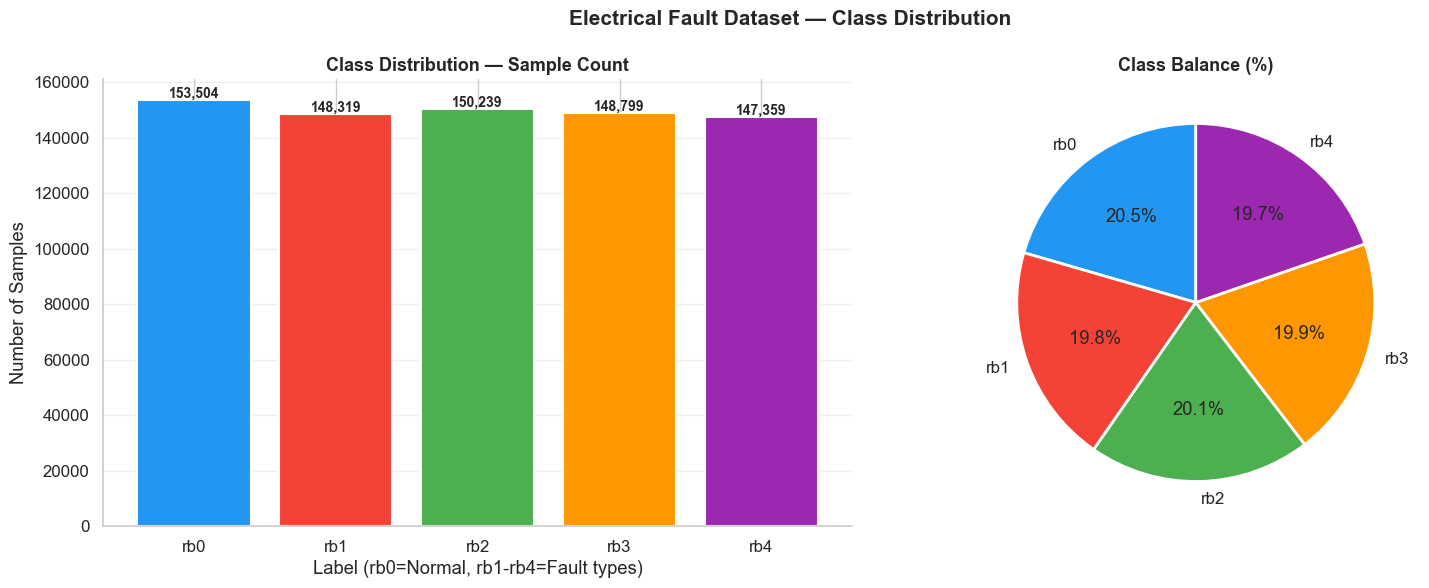

✅ Saved: 01_class_distribution.png


In [8]:
# ── Class distribution visualisation ─────────────────────────
CPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0',
        '#009688','#FF5722','#607D8B','#E91E63','#3F51B5']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Bar chart
ax = axes[0]
counts = df['label'].value_counts().sort_index()
labels_sorted = counts.index.tolist()
bars = ax.bar(labels_sorted, counts.values,
              color=CPLT[:len(labels_sorted)], edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{cnt:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Class Distribution — Sample Count', fontweight='bold', fontsize=13)
ax.set_xlabel('Label (rb0=Normal, rb1-rb4=Fault types)')
ax.set_ylabel('Number of Samples')
ax.grid(True, axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=labels_sorted, colors=CPLT[:len(labels_sorted)],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Class Balance (%)', fontweight='bold', fontsize=13)

plt.suptitle('Electrical Fault Dataset — Class Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 01_class_distribution.png')

## § 4 · Electrical Signal Visualisation

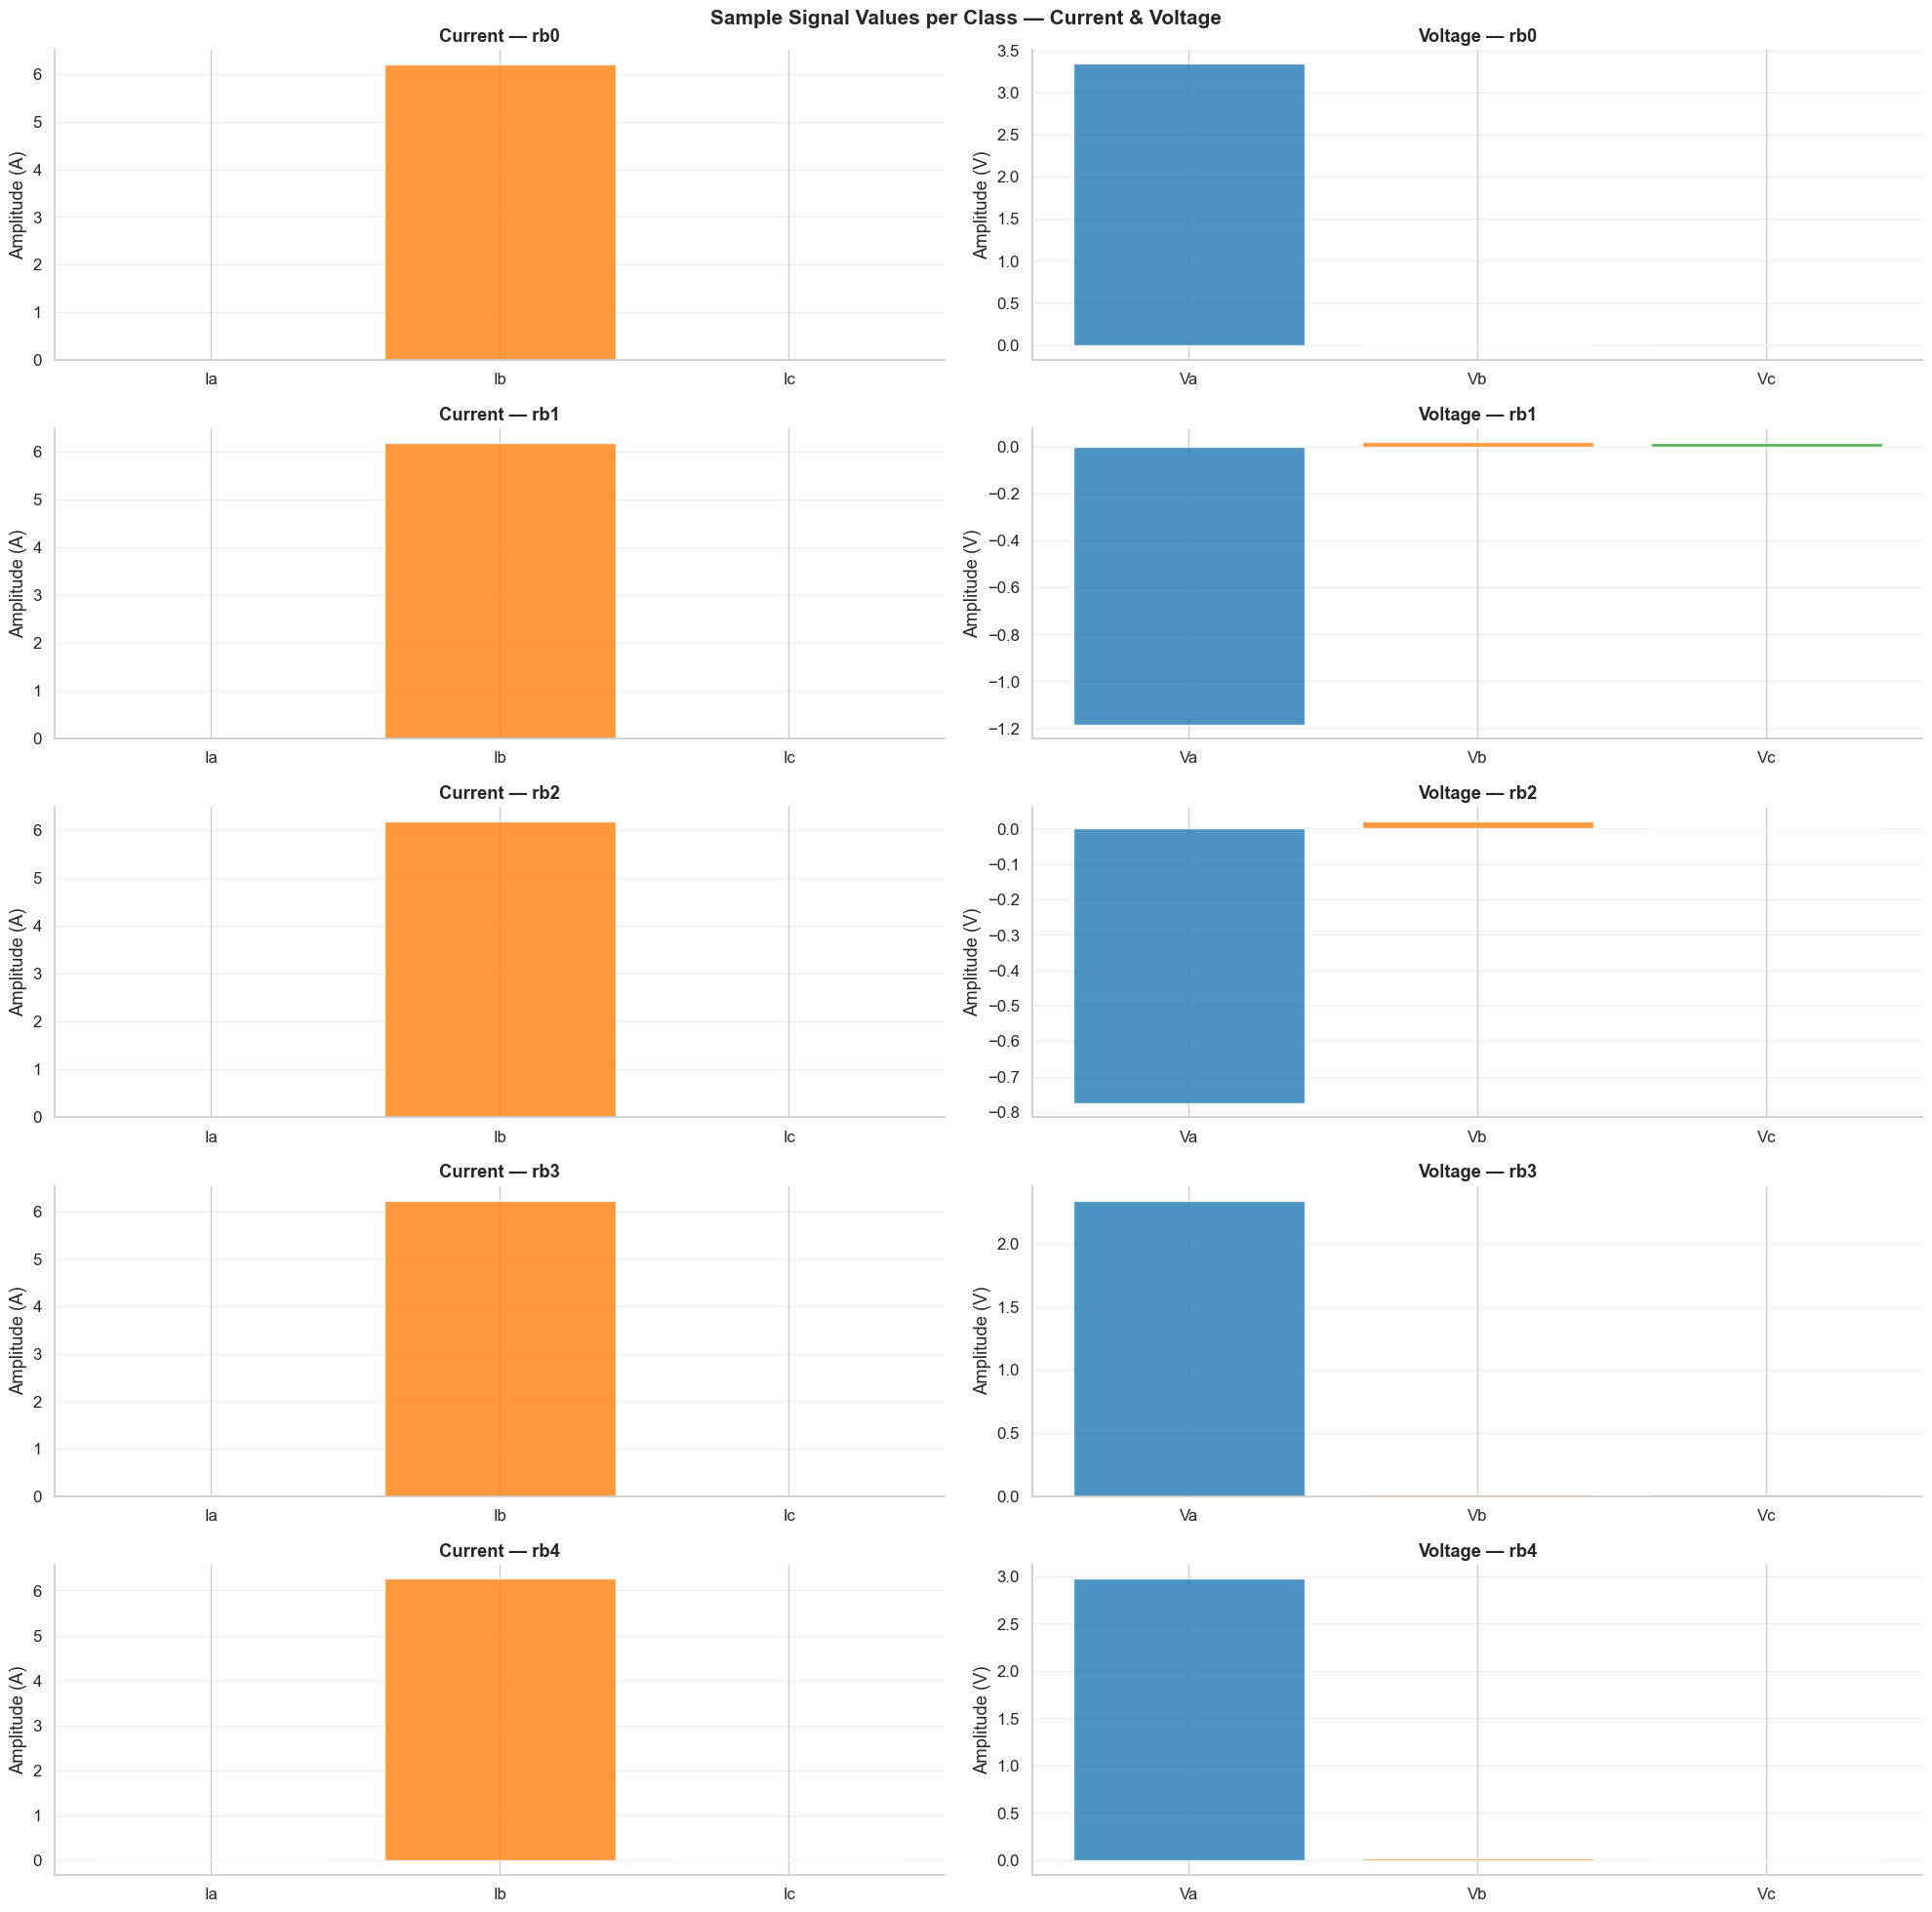

✅ Saved: 02_signal_per_class.png


In [9]:
CURRENT_FEATS = ['Ia', 'Ib', 'Ic']
VOLTAGE_FEATS = ['Va', 'Vb', 'Vc']
LABEL_ORDER   = sorted(df['label'].unique())
COLORS        = ['tab:blue','tab:orange','tab:green']

fig, axes = plt.subplots(len(LABEL_ORDER), 2,
                          figsize=(20, 4*len(LABEL_ORDER)), facecolor='white')
if len(LABEL_ORDER) == 1: axes = axes.reshape(1,-1)

for row, lbl in enumerate(LABEL_ORDER):
    sample = df[df['label']==lbl].iloc[0]
    # Current
    ax = axes[row, 0]
    for feat, col in zip(CURRENT_FEATS, COLORS):
        ax.bar(feat, sample[feat], color=col, alpha=0.8, edgecolor='white')
    ax.set_title(f'Current — {lbl}', fontweight='bold')
    ax.set_ylabel('Amplitude (A)'); ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    # Voltage
    ax2 = axes[row, 1]
    for feat, col in zip(VOLTAGE_FEATS, COLORS):
        ax2.bar(feat, sample[feat], color=col, alpha=0.8, edgecolor='white')
    ax2.set_title(f'Voltage — {lbl}', fontweight='bold')
    ax2.set_ylabel('Amplitude (V)'); ax2.grid(True, axis='y', alpha=0.3)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Sample Signal Values per Class — Current & Voltage',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('02_signal_per_class.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 02_signal_per_class.png')

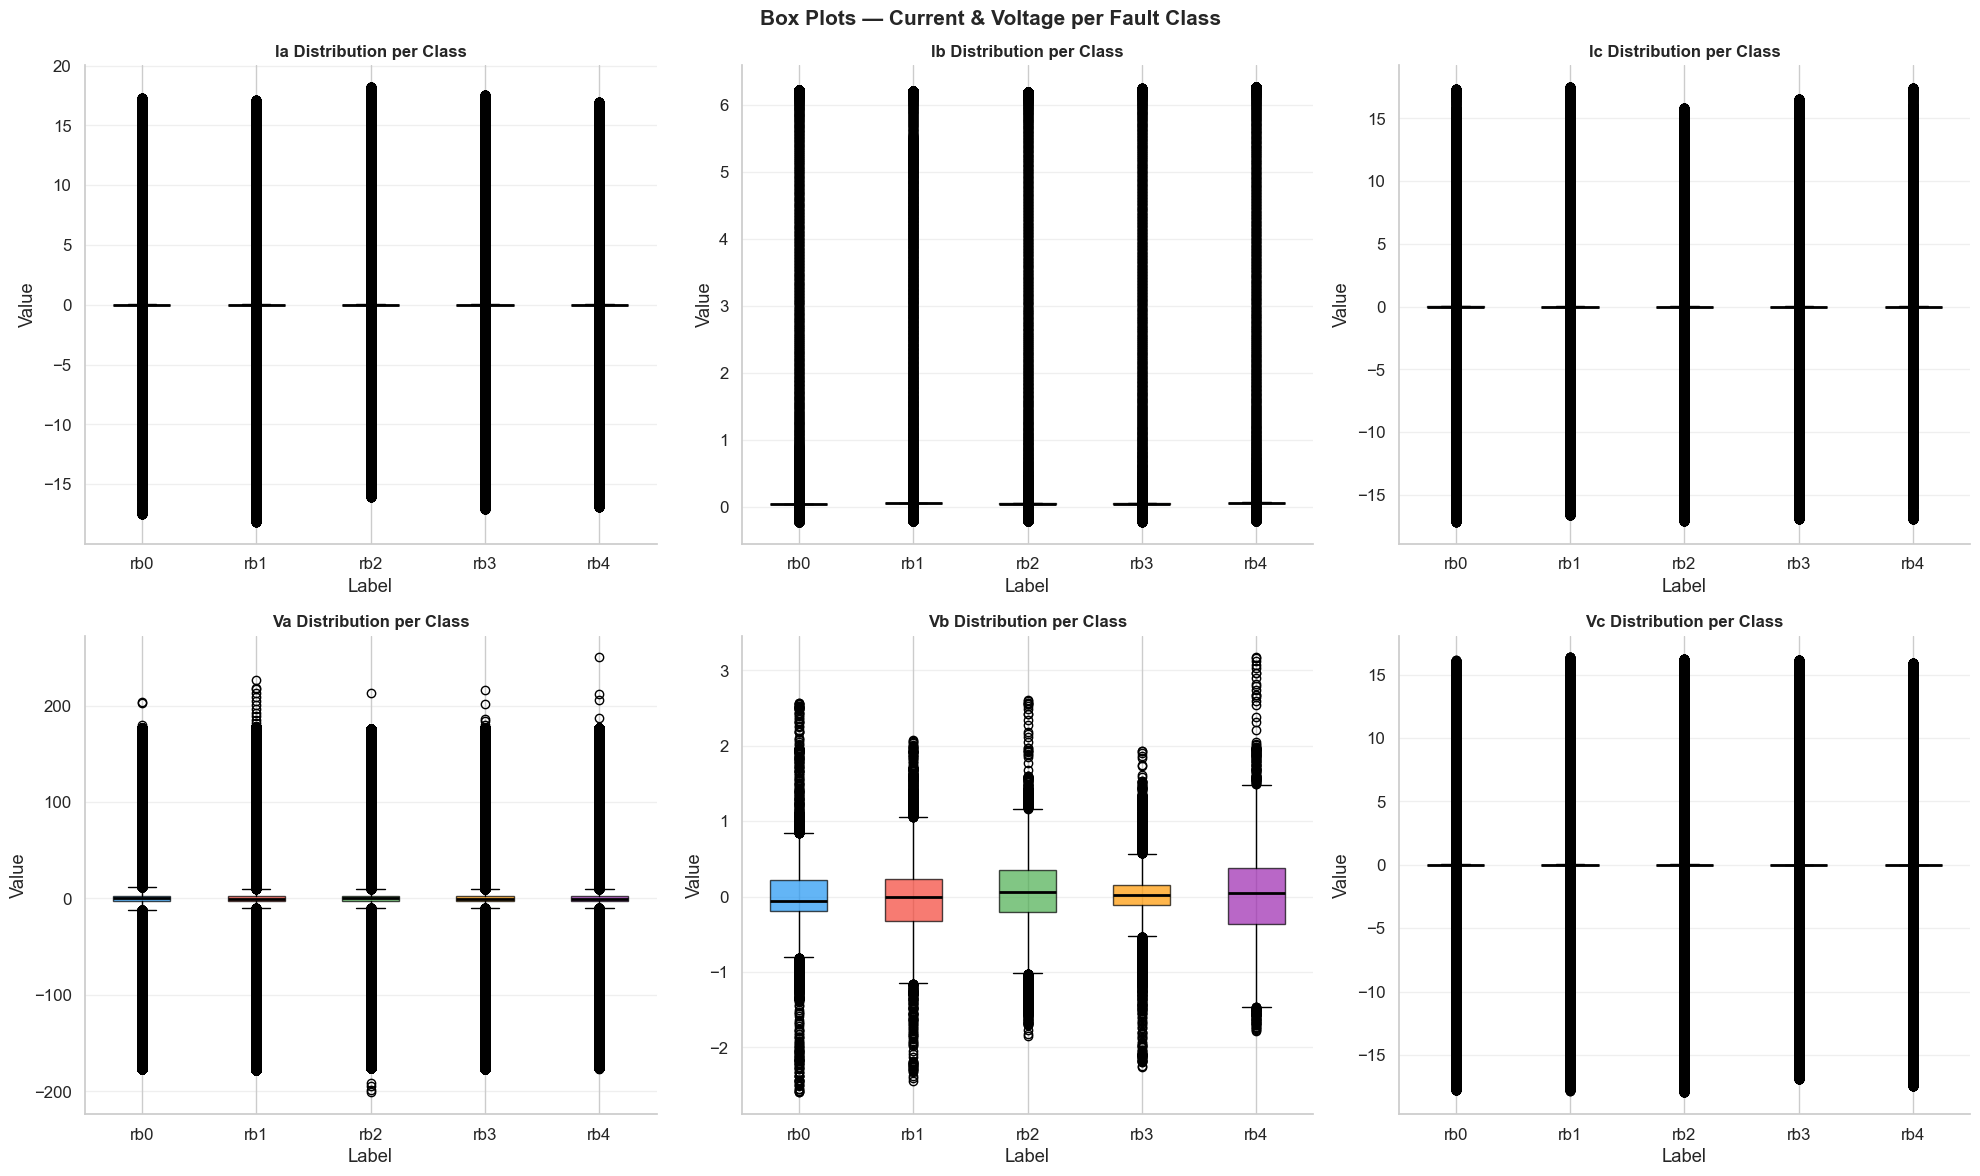

✅ Saved: 03_boxplots.png


In [10]:
# ── Box plots — current & voltage distribution per class ──────
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='white')
all_sig_feats = CURRENT_FEATS + VOLTAGE_FEATS

for i, feat in enumerate(all_sig_feats):
    ax = axes[i//3, i%3]
    data_per_class = [df[df['label']==lbl][feat].values for lbl in LABEL_ORDER]
    bp = ax.boxplot(data_per_class, labels=LABEL_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], CPLT[:len(LABEL_ORDER)]):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_title(f'{feat} Distribution per Class', fontweight='bold', fontsize=12)
    ax.set_xlabel('Label'); ax.set_ylabel('Value')
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Box Plots — Current & Voltage per Fault Class',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 03_boxplots.png')

## § 5 · Correlation Analysis

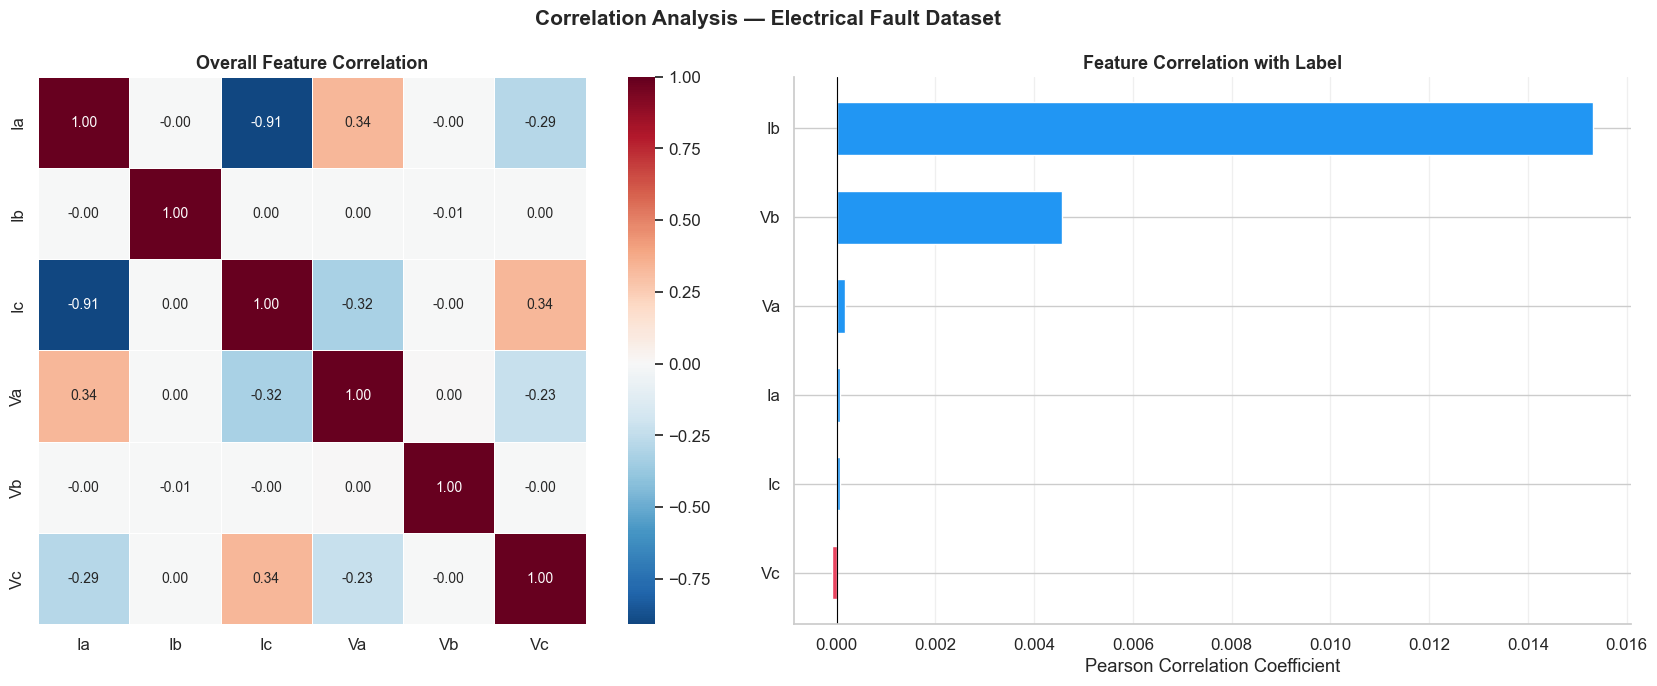

✅ Saved: 04_correlation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Overall correlation
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], linewidths=0.5, square=True,
            annot_kws={'size':10})
axes[0].set_title('Overall Feature Correlation', fontweight='bold', fontsize=13)

# Correlation with label (encoded)
le_corr = LabelEncoder()
df_corr  = df[FEATURES].copy()
df_corr['label_enc'] = le_corr.fit_transform(df['label'])
corr_label = df_corr.corr()['label_enc'].drop('label_enc').sort_values()
colors_c   = ['#E94560' if v < 0 else '#2196F3' for v in corr_label]
axes[1].barh(corr_label.index, corr_label.values,
             color=colors_c, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Label', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(True, axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Correlation Analysis — Electrical Fault Dataset',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 04_correlation.png')

## § 6 · Feature Engineering (Electrical Domain)

In [12]:
def engineer_features(df_in):
    """
    Derives 23 physically meaningful electrical features from 6 raw signals.
    No signal transformation — all algebraic combinations of Ia,Ib,Ic,Va,Vb,Vc.
    """
    d = df_in.copy()
    eps = 1e-8

    # ── Instantaneous power per phase ─────────────────────────
    d['P_a']     = d['Va'] * d['Ia']
    d['P_b']     = d['Vb'] * d['Ib']
    d['P_c']     = d['Vc'] * d['Ic']
    d['P_total'] = d['P_a'] + d['P_b'] + d['P_c']

    # ── Symmetrical components (magnitude proxies) ─────────────
    d['I_pos'] = (np.abs(d['Ia']) + np.abs(d['Ib']) + np.abs(d['Ic'])) / 3
    d['V_pos'] = (np.abs(d['Va']) + np.abs(d['Vb']) + np.abs(d['Vc'])) / 3
    d['I_neg'] = (np.abs(d['Ia']-d['Ib']) + np.abs(d['Ib']-d['Ic']) + np.abs(d['Ic']-d['Ia']))
    d['V_neg'] = (np.abs(d['Va']-d['Vb']) + np.abs(d['Vb']-d['Vc']) + np.abs(d['Vc']-d['Va']))

    # ── Zero sequence (ground fault indicator) ─────────────────
    d['I_zero'] = d['Ia'] + d['Ib'] + d['Ic']
    d['V_zero'] = d['Va'] + d['Vb'] + d['Vc']

    # ── Magnitudes ────────────────────────────────────────────
    d['I_mag_a'] = np.abs(d['Ia']); d['I_mag_b'] = np.abs(d['Ib']); d['I_mag_c'] = np.abs(d['Ic'])
    d['V_mag_a'] = np.abs(d['Va']); d['V_mag_b'] = np.abs(d['Vb']); d['V_mag_c'] = np.abs(d['Vc'])

    # ── RMS approximation ─────────────────────────────────────
    d['I_rms'] = np.sqrt((d['Ia']**2 + d['Ib']**2 + d['Ic']**2) / 3)
    d['V_rms'] = np.sqrt((d['Va']**2 + d['Vb']**2 + d['Vc']**2) / 3)

    # ── Imbalance ratios (key fault indicators) ────────────────
    d['I_imbalance'] = d['I_neg'] / (d['I_pos'] + eps)
    d['V_imbalance'] = d['V_neg'] / (d['V_pos'] + eps)

    # ── Phase ratios ──────────────────────────────────────────
    d['IaIb_ratio'] = d['Ia'] / (d['Ib'] + eps)
    d['VaVb_ratio'] = d['Va'] / (d['Vb'] + eps)

    # ── Impedance proxy ───────────────────────────────────────
    d['Z_a'] = d['Va'] / (d['Ia'] + eps)
    d['Z_b'] = d['Vb'] / (d['Ib'] + eps)
    d['Z_c'] = d['Vc'] / (d['Ic'] + eps)

    return d

df_eng = engineer_features(df)
ENGINEERED_FEATS = [c for c in df_eng.columns if c not in ['label'] + FEATURES]
ALL_FEATS = FEATURES + ENGINEERED_FEATS
N_FEATS   = len(ALL_FEATS)

print(f'Original features  : {len(FEATURES)}  → {FEATURES}')
print(f'Engineered features: {len(ENGINEERED_FEATS)}  → {ENGINEERED_FEATS}')
print(f'Total features     : {N_FEATS}')
display(df_eng[ALL_FEATS + ['label']].head(10).style
    .format(precision=4)
    .set_properties(**{'text-align':'center','font-size':'10px'})
    .set_table_styles([
        {'selector':'thead th','props':[('background','#0f3460'),('color','white'),('font-weight','bold')]}
    ]))

Original features  : 6  → ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
Engineered features: 25  → ['P_a', 'P_b', 'P_c', 'P_total', 'I_pos', 'V_pos', 'I_neg', 'V_neg', 'I_zero', 'V_zero', 'I_mag_a', 'I_mag_b', 'I_mag_c', 'V_mag_a', 'V_mag_b', 'V_mag_c', 'I_rms', 'V_rms', 'I_imbalance', 'V_imbalance', 'IaIb_ratio', 'VaVb_ratio', 'Z_a', 'Z_b', 'Z_c']
Total features     : 31


,Ia,Ib,Ic,Va,Vb,Vc,P_a,P_b,P_c,P_total,I_pos,V_pos,I_neg,V_neg,I_zero,V_zero,I_mag_a,I_mag_b,I_mag_c,V_mag_a,V_mag_b,V_mag_c,I_rms,V_rms,I_imbalance,V_imbalance,IaIb_ratio,VaVb_ratio,Z_a,Z_b,Z_c,label
0,0.0000,6.1710,0.0042,-1.1833,0.0183,0.0167,-0.0000,0.1130,0.0001,0.1131,2.0584,0.4061,12.3419,2.4033,6.1751,-1.1484,0.0000,6.1710,0.0042,1.1833,0.0183,0.0167,3.5628,0.6833,5.9960,5.9179,0.0000,-64.6257,-118333300.0000,0.0030,4.0000,rb1
1,0.0000,6.1691,0.0083,-1.2250,0.0031,0.0000,-0.0000,0.0188,0.0000,0.0188,2.0592,0.4094,12.3383,2.4561,6.1775,-1.2219,0.0000,6.1691,0.0083,1.2250,0.0031,0.0000,3.5618,0.7073,5.9919,6.0000,0.0000,-401.4067,-122500000.0000,0.0005,0.0000,rb1
2,0.0083,6.1694,-0.0042,-1.2500,0.0122,0.0083,-0.0104,0.0753,-0.0000,0.0649,2.0606,0.4235,12.3472,2.5244,6.1736,-1.2295,0.0083,6.1694,0.0042,1.2500,0.0122,0.0083,3.5619,0.7217,5.9919,5.9606,0.0014,-102.3999,-149.9998,0.0020,-2.0000,rb1
3,0.0167,6.1679,0.0000,-1.3000,0.0122,0.0042,-0.0217,0.0753,0.0000,0.0536,2.0615,0.4388,12.3358,2.6244,6.1846,-1.2836,0.0167,6.1679,0.0000,1.3000,0.0122,0.0042,3.5611,0.7506,5.9838,5.9810,0.0027,-106.4959,-77.9999,0.0020,416666.7000,rb1
4,0.0083,6.1685,-0.0042,-1.3417,0.0061,0.0042,-0.0112,0.0376,-0.0000,0.0265,2.0603,0.4506,12.3454,2.6955,6.1727,-1.3314,0.0083,6.1685,0.0042,1.3417,0.0061,0.0042,3.5614,0.7746,5.9919,5.9815,0.0014,-219.8183,-160.9999,0.0010,-1.0000,rb1
5,0.0042,6.1679,-0.0042,-1.3417,0.0061,0.0042,-0.0056,0.0376,-0.0000,0.0320,2.0587,0.4506,12.3441,2.6955,6.1679,-1.3314,0.0042,6.1679,0.0042,1.3417,0.0061,0.0042,3.5610,0.7746,5.9960,5.9815,0.0007,-219.8183,-321.9993,0.0010,-1.0000,rb1
6,-0.0042,6.1682,0.0167,-1.3250,0.0122,0.0000,0.0055,0.0753,0.0000,0.0808,2.0630,0.4457,12.3448,2.6744,6.1807,-1.3128,0.0042,6.1682,0.0167,1.3250,0.0122,0.0000,3.5612,0.7650,5.9838,6.0000,-0.0007,-108.5439,318.0007,0.0020,0.0000,rb1
7,0.0000,6.1676,0.0083,-1.3500,0.0092,0.0000,-0.0000,0.0565,0.0000,0.0565,2.0586,0.4531,12.3352,2.7183,6.1759,-1.3408,0.0000,6.1676,0.0083,1.3500,0.0092,0.0000,3.5609,0.7794,5.9919,6.0000,0.0000,-147.4558,-135000000.0000,0.0015,0.0000,rb1
8,0.0000,6.1676,0.0000,-1.3417,0.0122,0.0042,-0.0000,0.0753,0.0000,0.0753,2.0559,0.4527,12.3352,2.7077,6.1676,-1.3253,0.0000,6.1676,0.0000,1.3417,0.0122,0.0042,3.5609,0.7746,6.0000,5.9816,0.0000,-109.9093,-134166700.0000,0.0020,416666.7000,rb1
9,0.0042,6.1685,0.0083,-1.3417,0.0153,0.0000,-0.0056,0.0941,0.0000,0.0885,2.0603,0.4523,12.3287,2.7139,6.1810,-1.3264,0.0042,6.1685,0.0083,1.3417,0.0153,0.0000,3.5614,0.7747,5.9838,6.0000,0.0007,-87.9274,-321.9993,0.0025,0.0000,rb1


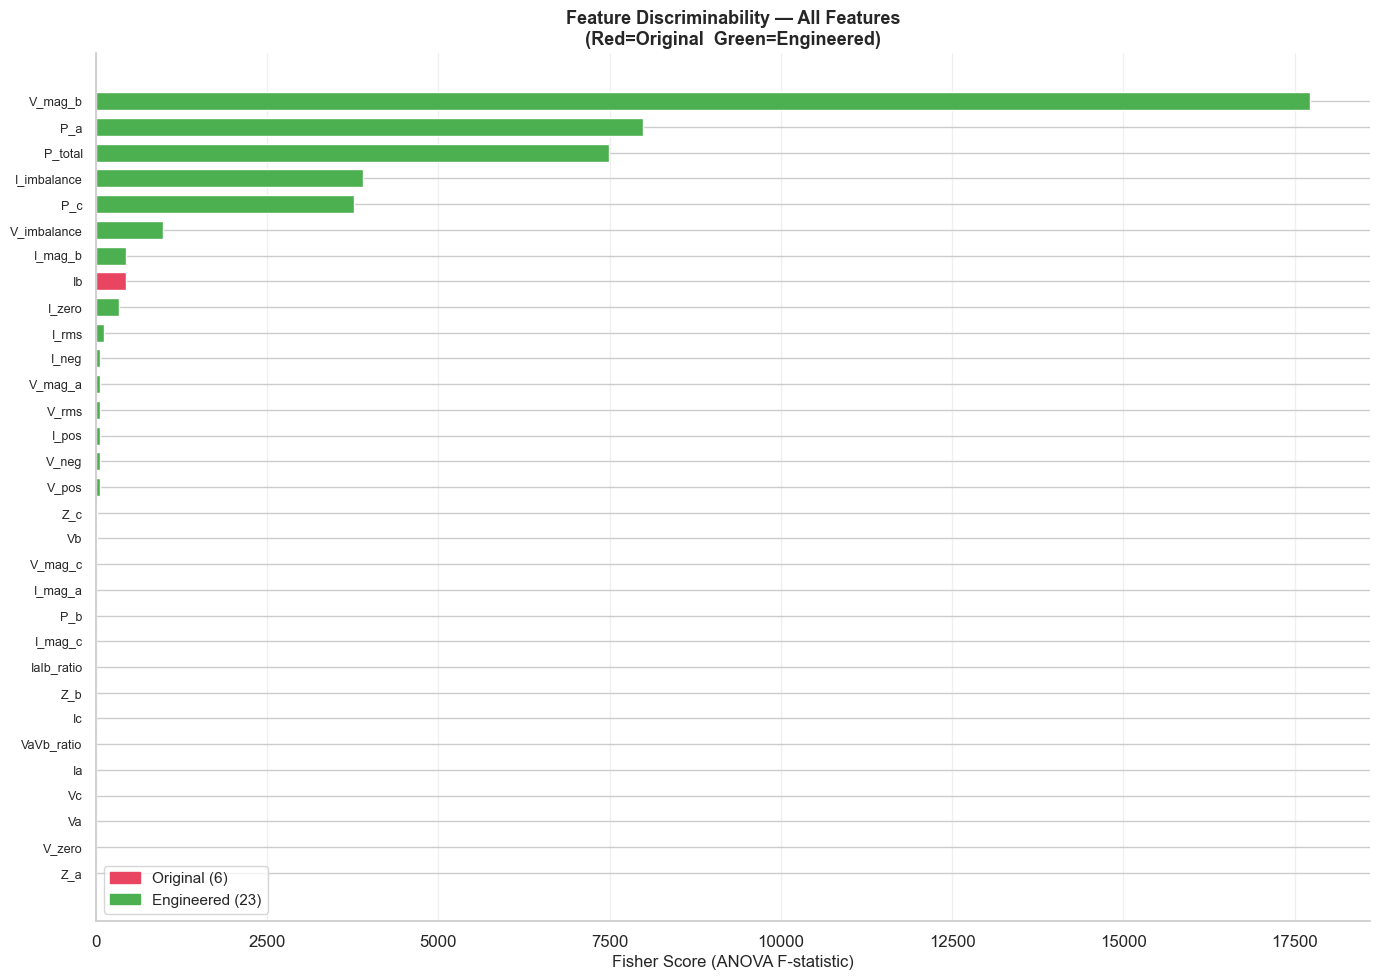

✅ Saved: 05_fisher_scores.png


In [13]:
# ── Fisher score of all features ─────────────────────────────
le_f = LabelEncoder()
y_f  = le_f.fit_transform(df_eng['label'])
f_scores, _ = f_classif(df_eng[ALL_FEATS].values, y_f)
fisher_s     = pd.Series(f_scores, index=ALL_FEATS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
colors_f = ['#E94560' if f in FEATURES else '#4CAF50' for f in fisher_s.index]
ax.barh(range(N_FEATS), fisher_s.values, color=colors_f, edgecolor='white', height=0.7)
ax.set_yticks(range(N_FEATS))
ax.set_yticklabels(fisher_s.index, fontsize=9)
ax.set_xlabel('Fisher Score (ANOVA F-statistic)', fontsize=12)
ax.set_title('Feature Discriminability — All Features\n(Red=Original  Green=Engineered)',
             fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
legend_els = [mpatches.Patch(color='#E94560', label='Original (6)'),
              mpatches.Patch(color='#4CAF50', label='Engineered (23)')]
ax.legend(handles=legend_els, fontsize=11)
plt.tight_layout()
plt.savefig('05_fisher_scores.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 05_fisher_scores.png')

## § 7 · Preprocessing, Split & SMOTE

In [14]:
X     = df_eng[ALL_FEATS].values.astype(np.float32)
y_raw = df_eng['label'].values

le          = LabelEncoder()
y           = le.fit_transform(y_raw)
CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)
print(f'Classes ({N_CLASSES}): {CLASS_NAMES}')
print(f'Encoded : {list(range(N_CLASSES))} → {CLASS_NAMES.tolist()}')

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# StandardScaler — fit on train only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set only
print(f'\nBefore SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f'After  SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')
print(f'\nTrain (SMOTE): {X_train_sm.shape}  Test: {X_test_sc.shape}')

# DL val split (stratified, from SMOTE train)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_STATE)
tr_idx_dl, val_idx_dl = next(sss.split(X_train_sm, y_train_sm))
X_dl_tr  = X_train_sm[tr_idx_dl];  y_dl_tr  = y_train_sm[tr_idx_dl]
X_dl_val = X_train_sm[val_idx_dl]; y_dl_val = y_train_sm[val_idx_dl]
print(f'DL fit : {X_dl_tr.shape}  DL val: {X_dl_val.shape}')

Classes (5): ['rb0' 'rb1' 'rb2' 'rb3' 'rb4']
Encoded : [0, 1, 2, 3, 4] → ['rb0', 'rb1', 'rb2', 'rb3', 'rb4']

Before SMOTE: {np.int64(0): np.int64(122803), np.int64(1): np.int64(118655), np.int64(2): np.int64(120191), np.int64(3): np.int64(119039), np.int64(4): np.int64(117888)}
After  SMOTE: {np.int64(0): np.int64(122803), np.int64(1): np.int64(122803), np.int64(2): np.int64(122803), np.int64(3): np.int64(122803), np.int64(4): np.int64(122803)}

Train (SMOTE): (614015, 31)  Test: (149644, 31)
DL fit : (552613, 31)  DL val: (61402, 31)


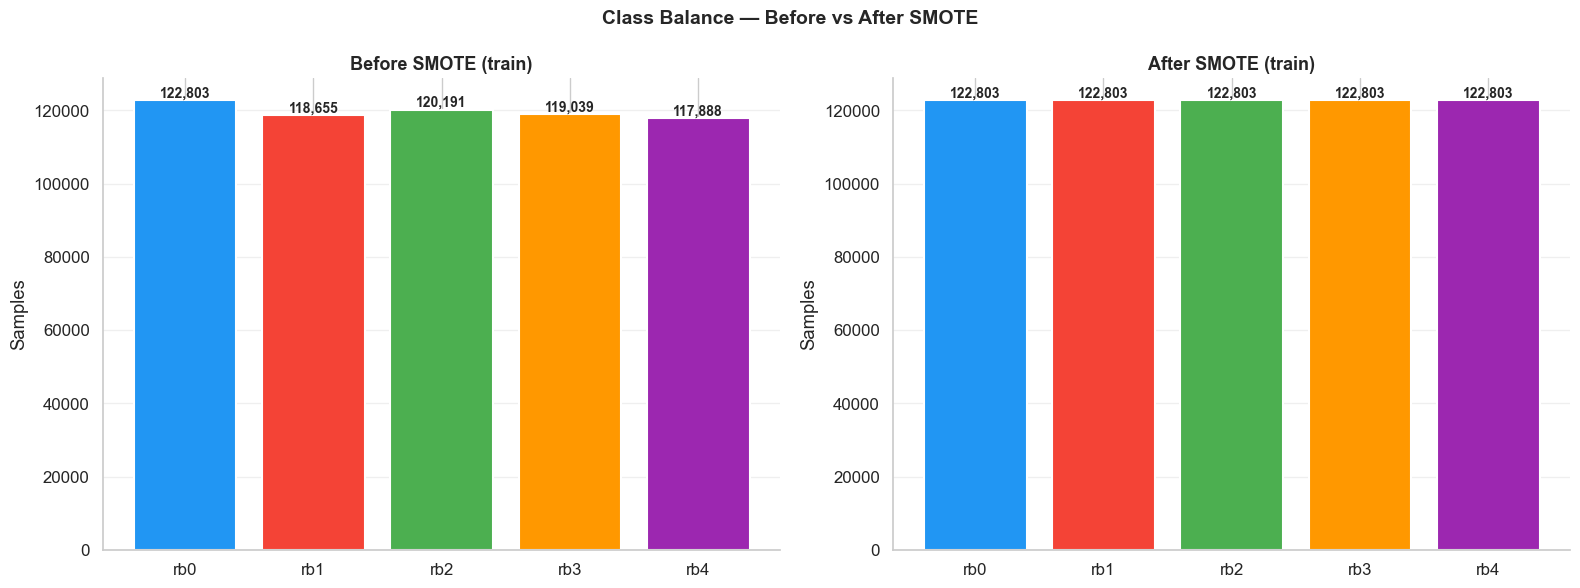

✅ Saved: 06_smote_balance.png


In [15]:
# ── SMOTE before/after visualisation ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
for ax, ys, title in zip(axes,
                          [y_train, y_train_sm],
                          ['Before SMOTE (train)', 'After SMOTE (train)']):
    uniq, cnts = np.unique(ys, return_counts=True)
    bars = ax.bar(CLASS_NAMES[uniq], cnts,
                  color=CPLT[:len(uniq)], edgecolor='white', linewidth=1.5)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{cnt:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Samples'); ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Class Balance — Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_smote_balance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 06_smote_balance.png')

## § 8 · Evaluation Helpers

In [16]:
RESULTS   = {}
ml_preds  = {}
ml_probs  = {}
ml_models = {}   # stores trained model objects for SHAP/LIME

def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    t0 = time.time() if 'time' in dir() else 0
    import time as _time; t0 = _time.time()
    model.fit(Xtr, ytr)
    t1 = _time.time()
    yp = model.predict(Xte)
    acc  = accuracy_score(yte, yp)
    prec = precision_score(yte, yp, average='weighted', zero_division=0)
    rec  = recall_score(yte, yp, average='weighted', zero_division=0)
    f1   = f1_score(yte, yp, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(yte, yp)
    try:
        prob = model.predict_proba(Xte)
        auc_sc = roc_auc_score(to_categorical(yte, N_CLASSES), prob,
                                multi_class='ovr', average='weighted')
    except:
        prob   = None
        auc_sc = 0.0
    RESULTS[name]   = dict(Accuracy=round(acc*100,2), Precision=round(prec*100,2),
                            Recall=round(rec*100,2), F1=round(f1*100,2),
                            MCC=round(mcc,4), AUC=round(auc_sc,4),
                            Time=round(t1-t0,1))
    ml_preds[name]  = yp
    ml_probs[name]  = prob
    ml_models[name] = model
    flag = '✅' if acc >= 0.90 else '⚠️'
    print(f'  {flag} {name:<22} Acc={acc*100:.2f}%  F1={f1*100:.2f}%  MCC={mcc:.4f}  AUC={auc_sc:.4f}  ({t1-t0:.1f}s)')

import time
print('✅ Evaluation helpers ready — models saved to ml_models dict')

✅ Evaluation helpers ready — models saved to ml_models dict


## § 9 · Train Classical ML Models

### 9.1 Decision Tree

In [17]:
print('Training Decision Tree...')
evaluate_model('Decision Tree',
    DecisionTreeClassifier(max_depth=None, 
                           min_samples_leaf=1,
                           class_weight='balanced', 
                           random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training Decision Tree...
  ⚠️ Decision Tree          Acc=87.51%  F1=87.51%  MCC=0.8439  AUC=0.9220  (94.4s)


### 9.2 Random Forest

In [18]:
print('Training Random Forest...')
evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=300, 
                           max_depth=None,
                           min_samples_leaf=1, 
                           class_weight='balanced',
                           n_jobs=-1, 
                           random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training Random Forest...
  ✅ Random Forest          Acc=91.24%  F1=91.21%  MCC=0.8908  AUC=0.9915  (1384.1s)


### 9.3 XGBoost

In [20]:
print('Training XGBoost...')
evaluate_model('XGBoost',
    xgb.XGBClassifier(n_estimators=300, 
                      max_depth=8, 
                      learning_rate=0.05,
                      subsample=0.8, 
                      colsample_bytree=0.8,
                      objective='multi:softprob', 
                      num_class=N_CLASSES,
                      eval_metric='mlogloss', 
                      verbosity=0,
                      random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training XGBoost...
  ✅ XGBoost                Acc=91.41%  F1=91.38%  MCC=0.8930  AUC=0.9923  (279.0s)


### 9.4 LightGBM

In [21]:
print('Training LightGBM...')
evaluate_model('LightGBM',
    lgb.LGBMClassifier(n_estimators=300, 
                       num_leaves=63, 
                       max_depth=10,
                       learning_rate=0.05, 
                       subsample=0.8, 
                       colsample_bytree=0.8,
                       objective='multiclass', 
                       num_class=N_CLASSES,
                       verbose=-1, 
                       random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training LightGBM...
  ✅ LightGBM               Acc=91.57%  F1=91.54%  MCC=0.8950  AUC=0.9926  (111.2s)


### 9.5 HistGradBoost

In [22]:
print('Training HistGradientBoosting...')
evaluate_model('HistGradBoost',
    HistGradientBoostingClassifier(max_iter=300, 
                                   max_depth=8,
                                   learning_rate=0.05, 
                                   min_samples_leaf=20,
                                   l2_regularization=0.1, 
                                   random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training HistGradientBoosting...
  ✅ HistGradBoost          Acc=91.36%  F1=91.33%  MCC=0.8924  AUC=0.9922  (170.8s)


### 9.6 SVM

In [23]:
print('Training SVM (subset for speed)...')
MAX_SVM = 20000
idx_sub = np.random.choice(len(X_train_sm), 
                           min(MAX_SVM, len(X_train_sm)), 
                           replace=False)
evaluate_model('SVM',
    SVC(kernel='rbf', 
    C=10.0, gamma='scale',
    class_weight='balanced', 
    probability=True, 
    random_state=RANDOM_STATE),
               
    X_train_sm[idx_sub], X_test_sc, y_train_sm[idx_sub], y_test)

Training SVM (subset for speed)...
  ⚠️ SVM                    Acc=54.78%  F1=54.53%  MCC=0.4413  AUC=0.8264  (477.6s)


### 9.7 KNN

In [24]:
print('Training KNN...')
evaluate_model('KNN',
    KNeighborsClassifier(n_neighbors=7, 
                         metric='euclidean', 
                         n_jobs=-1),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training KNN...
  ⚠️ KNN                    Acc=71.92%  F1=71.87%  MCC=0.6492  AUC=0.9182  (0.1s)


### 9.8 MLP

In [25]:
print('Training MLP...')
evaluate_model('MLP',
    MLPClassifier(hidden_layer_sizes=(256,128,64), 
                  activation='relu',
                  solver='adam', 
                  alpha=0.001, 
                  batch_size=512,
                  learning_rate_init=1e-3,
                  max_iter=200,
                  early_stopping=True, 
                  validation_fraction=0.1,
                  n_iter_no_change=15, 
                  random_state=RANDOM_STATE),
               
    X_train_sm, X_test_sc, y_train_sm, y_test)

Training MLP...
  ⚠️ MLP                    Acc=88.05%  F1=87.92%  MCC=0.8514  AUC=0.9862  (5168.9s)


### 9.8.1 Confusion matrix

In [ ]:
# ══════════════════════════════════════════════════════════════
# SEPARATE CONFUSION MATRIX FOR EACH MODEL
# ══════════════════════════════════════════════════════════════
print('Plotting individual confusion matrices...')

for mname, yp in ml_preds.items():
    acc = RESULTS[mname]['Accuracy']
    flag = '✅' if acc >= 90 else '⚠️'

    fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
    cm = confusion_matrix(y_test, yp)

    # Normalised % for annotations
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Custom annotation: count + percentage
    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.1f}%)'
                       for j in range(N_CLASSES)]
                      for i in range(N_CLASSES)])

    sns.heatmap(cm, ax=ax,
                annot=annot, fmt='',
                cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                linewidths=0.8,
                linecolor='white',
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 10, 'weight': 'bold'})

    ax.set_title(f'{flag} {mname}\nAccuracy = {acc:.2f}%',
                 fontsize=14, fontweight='bold', pad=14,
                 color='#1b5e20' if acc >= 90 else '#b71c1c')
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label',      fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    fname = f'cm_{mname.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  ✅ Saved: {fname}')


# ══════════════════════════════════════════════════════════════
# COMBINED ROC-AUC CURVES — ALL MODELS IN ONE FIGURE
# ══════════════════════════════════════════════════════════════
print('\nPlotting combined ROC-AUC curves...')

# Models that have predict_proba
models_with_prob = {n: p for n, p in ml_probs.items()
                    if p is not None and
                    hasattr(p, 'ndim') and
                    p.ndim == 2 and
                    p.shape[1] == N_CLASSES}

n_models = len(models_with_prob)
n_cols   = 4
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(7*n_cols, 6*n_rows),
                          facecolor='white')
axes = axes.flat

line_colors = sns.color_palette('tab10', N_CLASSES)
line_styles = ['-','--','-.',':','--']

for ax, (mname, prob) in zip(axes, models_with_prob.items()):
    auc_per_class = []
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_cat[:, i], prob[:, i])
        roc_auc_val = auc(fpr, tpr)
        auc_per_class.append(roc_auc_val)
        ax.plot(fpr, tpr,
                color=line_colors[i],
                lw=2,
                linestyle=line_styles[i % len(line_styles)],
                label=f'{cls} (AUC={roc_auc_val:.3f})')

    # Diagonal reference
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')

    mean_auc = np.mean(auc_per_class)
    acc_val  = RESULTS[mname]['Accuracy']
    flag     = '✅' if acc_val >= 90 else '⚠️'

    ax.set_title(f'{flag} {mname}\nMean AUC = {mean_auc:.4f}',
                 fontweight='bold', fontsize=12,
                 color='#1b5e20' if acc_val >= 90 else '#b71c1c')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate',  fontsize=10)
    ax.legend(fontsize=7.5, loc='lower right',
              frameon=True, framealpha=0.9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for ax in list(axes)[n_models:]:
    ax.set_visible(False)

plt.suptitle('ROC-AUC Curves — All Models | Electrical Fault Classification',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_auc_all_models.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: roc_auc_all_models.png')


# ══════════════════════════════════════════════════════════════
# BONUS: SINGLE OVERLAY ROC PLOT — best class from each model
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

model_colors = sns.color_palette('tab10', n_models)

for color, (mname, prob) in zip(model_colors, models_with_prob.items()):
    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_test_cat[:, i], prob[:, i])[0]
        for i in range(N_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(N_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(y_test_cat[:, i], prob[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= N_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)

    ax.plot(all_fpr, mean_tpr,
            color=color, lw=2.5,
            label=f'{mname}  (macro AUC={macro_auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate',  fontsize=13, fontweight='bold')
ax.set_title('Macro-Average ROC Curve — All Models Overlay\n'
             'Electrical Fault Classification',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right',
          frameon=True, framealpha=0.95, edgecolor='#CCC')
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc_auc_overlay.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: roc_auc_overlay.png')

## § 10 · Deep Learning Models

In [26]:
DL_CB = [
    EarlyStopping(monitor='val_loss', 
                  patience=10,
                  restore_best_weights=True, 
                  verbose=1),
    
    ReduceLROnPlateau(monitor='val_loss', 
                      factor=0.5,
                      patience=5, 
                      min_lr=1e-6, 
                      verbose=0)
]
y_dl_tr_cat  = to_categorical(y_dl_tr,  N_CLASSES)
y_dl_val_cat = to_categorical(y_dl_val, N_CLASSES)
y_test_cat   = to_categorical(y_test,   N_CLASSES)
print('✅ DL setup complete')

✅ DL setup complete


### 10.1 DNN on Engineered Features

In [29]:
print('Training DNN (residual architecture)...')
tf.random.set_seed(RANDOM_STATE)

# ── Use original 29 features only — polynomial was too noisy ──
# ── Higher learning rate — 5e-4 was too slow to escape plateau ─
# ── Residual connections — prevent gradient vanishing on tabular data

inp_dnn = Input(shape=(N_FEATS,))

# ── Stem ──────────────────────────────────────────────────────
x = Dense(256)(inp_dnn)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

# ── Residual Block 1 ──────────────────────────────────────────
x_skip = x
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip])   # skip connection
x = Activation('relu')(x)

# ── Residual Block 2 ──────────────────────────────────────────
x_skip2 = x
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.25)(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip2])
x = Activation('relu')(x)

# ── Head ──────────────────────────────────────────────────────
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.2)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.15)(x)

out_dnn = Dense(N_CLASSES, activation='softmax')(x)

dnn = Model(inp_dnn, out_dnn)
dnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
dnn.summary()

# ── Use original SMOTE split — not polynomial ──────────────────
DL_CB_DNN = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        mode='max', verbose=1),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5, patience=8,
        min_lr=1e-6, mode='max', verbose=0)
]

t0 = time.time()
dnn_h = dnn.fit(
    X_dl_tr, y_dl_tr_cat,
    epochs     = 150,
    batch_size = 512,
    validation_data = (X_dl_val, y_dl_val_cat),
    callbacks  = DL_CB_DNN,
    shuffle    = True,
    verbose    = 1)
dnn_t = time.time() - t0

dnn_prob = dnn.predict(X_test_sc, verbose=0)
dnn_pred = np.argmax(dnn_prob, axis=1)

acc    = accuracy_score(y_test, dnn_pred)
prec   = precision_score(y_test, dnn_pred, average='weighted', zero_division=0)
rec    = recall_score(y_test, dnn_pred, average='weighted', zero_division=0)
f1     = f1_score(y_test, dnn_pred, average='weighted', zero_division=0)
mcc    = matthews_corrcoef(y_test, dnn_pred)
auc_sc = roc_auc_score(y_test_cat, dnn_prob,
                        multi_class='ovr', average='weighted')

RESULTS['DNN']  = dict(Accuracy=round(acc*100,2), Precision=round(prec*100,2),
                        Recall=round(rec*100,2), F1=round(f1*100,2),
                        MCC=round(mcc,4), AUC=round(auc_sc,4),
                        Time=round(dnn_t,1))
ml_preds['DNN'] = dnn_pred
ml_probs['DNN'] = dnn_prob

flag = '✅' if acc >= 0.90 else '⚠️'
print(f'  {flag} DNN  Acc={acc*100:.2f}%  F1={f1*100:.2f}%  '
      f'MCC={mcc:.4f}  AUC={auc_sc:.4f}  ({dnn_t:.0f}s)')
print(f'  Best val_acc : {max(dnn_h.history["val_accuracy"])*100:.2f}%')
print(f'  Epochs ran   : {len(dnn_h.history["accuracy"])}')

Training DNN (residual architecture)...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 31)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 256)               │           8,192 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 256)               │           1,024 │ dense_10[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_8 (Activation)     │ (None, 256)               │               0 │ batch_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 256)               │               0 │ activation_8[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 256)               │          65,792 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 256)               │           1,024 │ dense_11[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_9 (Activation)     │ (None, 256)               │               0 │ batch_normalization_9[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 256)               │               0 │ activation_9[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 256)               │          65,792 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 256)               │           1,024 │ dense_12[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256)               │               0 │ batch_normalization_10[0]… │
│                               │                           │                 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_10 (Activation)    │ (None, 256)               │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 256)               │          65,792 │ activation_10[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 256)               │           1,024 │ dense_13[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 318,725 (1.22 MB)

 Trainable params: 315,781 (1.20 MB)

 Non-trainable params: 2,944 (11.50 KB)

Epoch 1/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 116s 99ms/step - accuracy: 0.5008 - loss: 1.1514 - val_accuracy: 0.5505 - val_loss: 1.0312 - learning_rate: 0.0010
Epoch 2/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 108s 100ms/step - accuracy: 0.5606 - loss: 1.0234 - val_accuracy: 0.5722 - val_loss: 0.9919 - learning_rate: 0.0010
Epoch 3/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 112s 104ms/step - accuracy: 0.5769 - loss: 0.9901 - val_accuracy: 0.5808 - val_loss: 0.9714 - learning_rate: 0.0010
Epoch 4/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 107s 99ms/step - accuracy: 0.5919 - loss: 0.9626 - val_accuracy: 0.6081 - val_loss: 0.9228 - learning_rate: 0.0010
Epoch 5/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 115s 106ms/step - accuracy: 0.6071 - loss: 0.9329 - val_accuracy: 0.6319 - val_loss: 0.8700 - learning_rate: 0.0010
Epoch 6/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 120s 111ms/step - accuracy: 0.6231 - loss: 0.8982 - val_accuracy: 0.6751 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 7/150
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 144s 

### 10.3 Training Curves

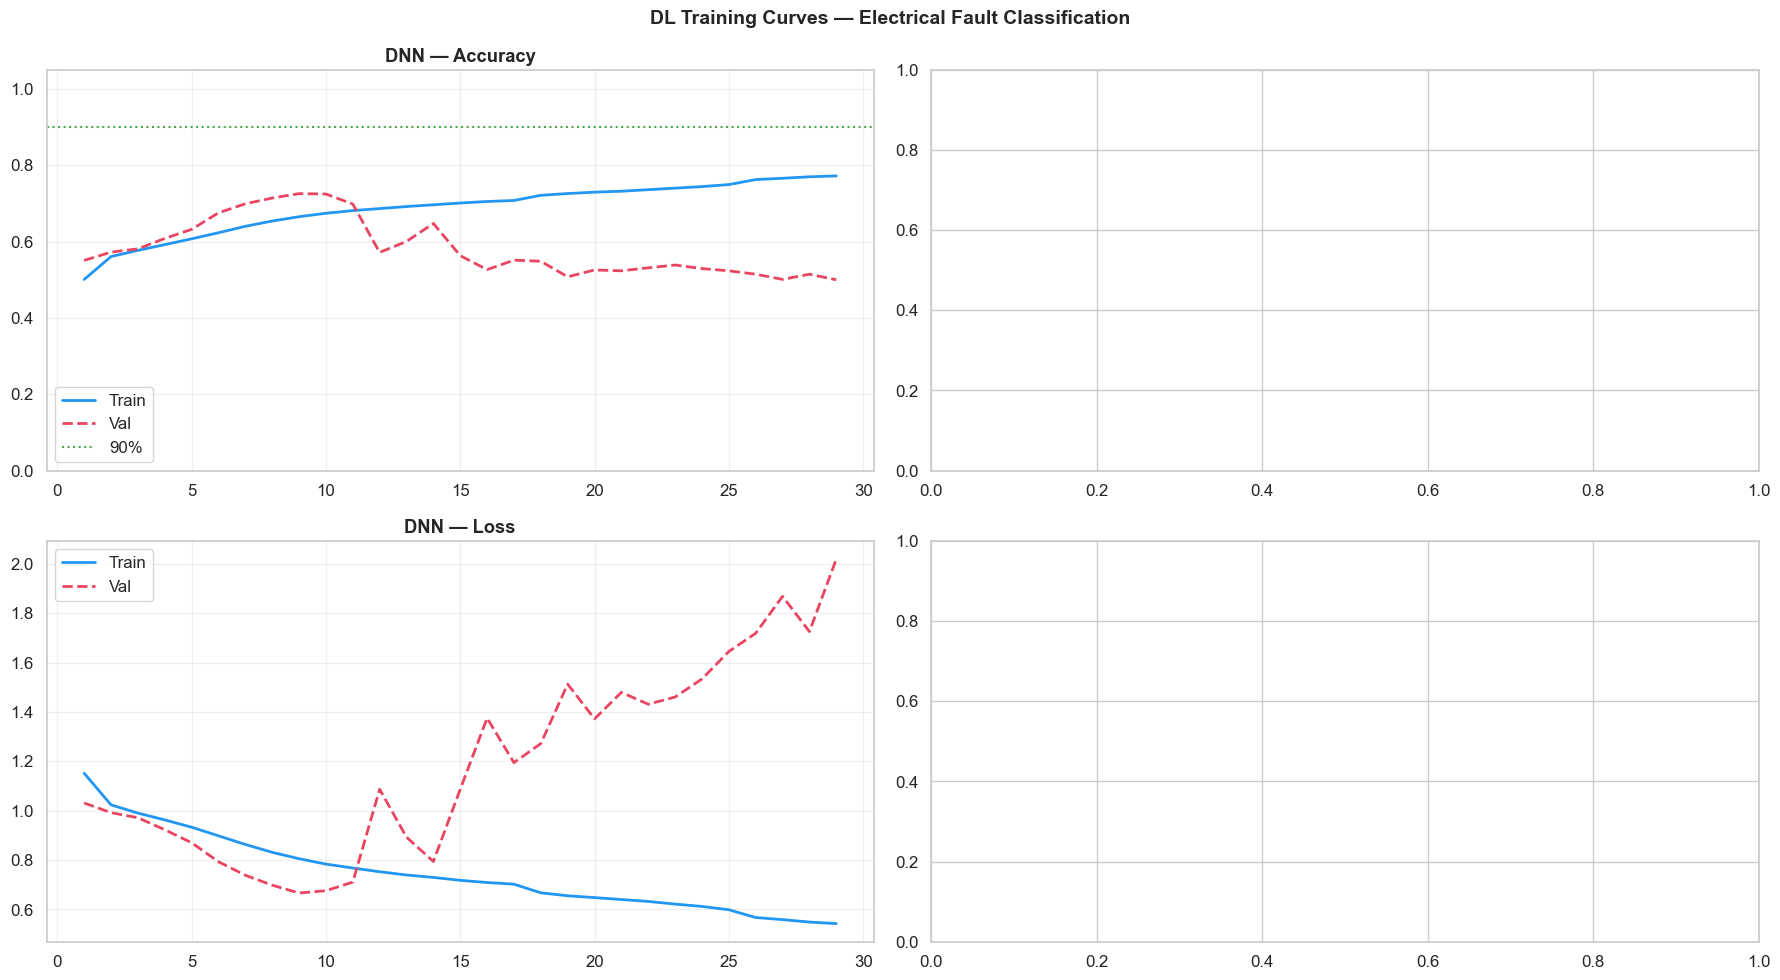

✅ Saved: 07_dl_curves.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor='white')
for col, (mname, hist) in enumerate(zip(['DNN',],[dnn_h])):
    ep = range(1, len(hist.history['accuracy'])+1)
    axes[0,col].plot(ep, hist.history['accuracy'],     '#2196F3', lw=2, label='Train')
    axes[0,col].plot(ep, hist.history['val_accuracy'], '#E94560', lw=2, label='Val', ls='--')
    axes[0,col].axhline(0.9, color='green', ls=':', lw=1.5, alpha=0.7, label='90%')
    axes[0,col].set_title(f'{mname} — Accuracy', fontweight='bold')
    axes[0,col].set_ylim(0,1.05); axes[0,col].legend(); axes[0,col].grid(True, alpha=0.3)

    axes[1,col].plot(ep, hist.history['loss'],     '#2196F3', lw=2, label='Train')
    axes[1,col].plot(ep, hist.history['val_loss'], '#E94560', lw=2, label='Val', ls='--')
    axes[1,col].set_title(f'{mname} — Loss', fontweight='bold')
    axes[1,col].legend(); axes[1,col].grid(True, alpha=0.3)

plt.suptitle('DL Training Curves — Electrical Fault Classification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_dl_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 07_dl_curves.png')

## § 11 · Model Comparison Dashboard

In [36]:
results_df = pd.DataFrame(RESULTS).T.sort_values('Accuracy', ascending=False)
print('='*95)
print('  ELECTRICAL FAULT CLASSIFICATION — ALL MODEL RESULTS')
print('='*95)
display(results_df.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1','MCC','AUC'])
    .format({'Accuracy':'{:.2f}%','Precision':'{:.2f}%','Recall':'{:.2f}%',
             'F1':'{:.2f}%','MCC':'{:.4f}','AUC':'{:.4f}','Time':'{:.1f}s'})
    .set_properties(**{'text-align':'center','font-size':'11px'})
    .set_table_styles([
        {'selector':'thead th','props':[('background','#0f3460'),('color','white'),('font-weight','bold')]}
    ]))
above_90 = results_df[results_df['Accuracy']>=90]
print(f'\nModels achieving ≥90%: {len(above_90)}/{len(results_df)}')

  ELECTRICAL FAULT CLASSIFICATION — ALL MODEL RESULTS


,Accuracy,Precision,Recall,F1,MCC,AUC,Time
LightGBM,91.57%,91.67%,91.57%,91.54%,0.8950,0.9926,111.2s
XGBoost,91.41%,91.51%,91.41%,91.38%,0.8930,0.9923,279.0s
HistGradBoost,91.36%,91.45%,91.36%,91.33%,0.8924,0.9922,170.8s
Random Forest,91.24%,91.30%,91.24%,91.21%,0.8908,0.9915,1384.1s
MLP,88.05%,88.14%,88.05%,87.92%,0.8514,0.9862,5168.9s
Decision Tree,87.51%,87.51%,87.51%,87.51%,0.8439,0.9220,94.4s
DNN,72.90%,72.85%,72.90%,72.71%,0.6619,0.9434,3612.2s
KNN,71.92%,71.94%,71.92%,71.87%,0.6492,0.9182,0.1s
SVM,54.78%,57.39%,54.78%,54.53%,0.4413,0.8264,477.6s



Models achieving ≥90%: 4/9


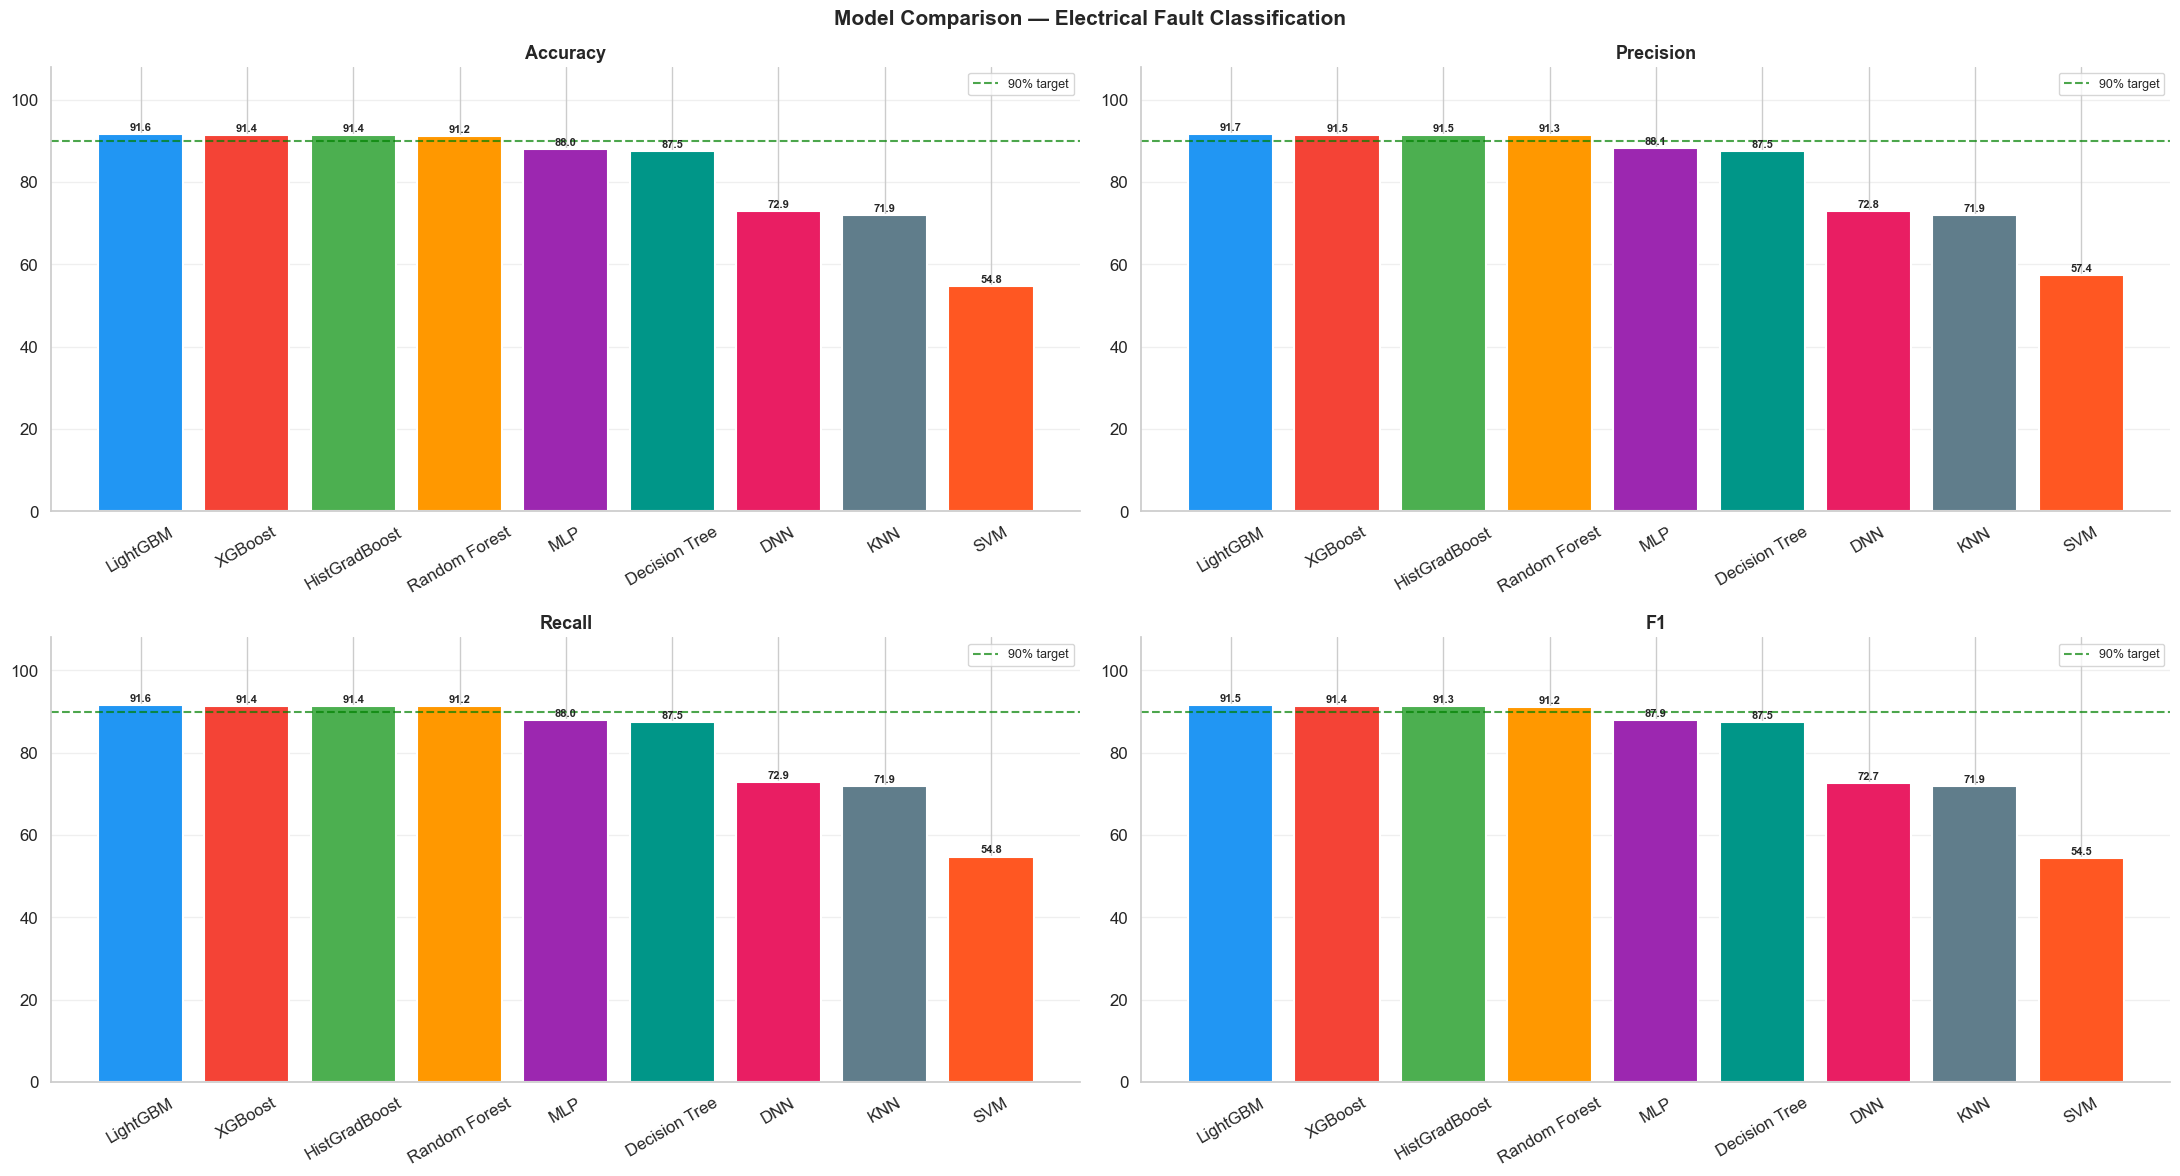

✅ Saved: 08_model_comparison.png


In [37]:
# ── Grouped bar comparison ────────────────────────────────────
metrics_show = ['Accuracy','Precision','Recall','F1']
fig, axes = plt.subplots(2, 2, figsize=(22,12), facecolor='white')
model_names = results_df.index.tolist()
MCPLT = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0',
         '#009688','#E91E63','#607D8B','#FF5722','#3F51B5']

for ax, metric in zip(axes.flat, metrics_show):
    vals = [float(results_df.loc[m, metric]) for m in model_names]
    bars = ax.bar(model_names, vals, color=MCPLT[:len(model_names)],
                  edgecolor='white', linewidth=1.5)
    ax.axhline(90, color='green', ls='--', lw=1.5, alpha=0.7, label='90% target')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylim(0,108); ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3); ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison — Electrical Fault Classification',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 08_model_comparison.png')

## § 12 · Confusion Matrices

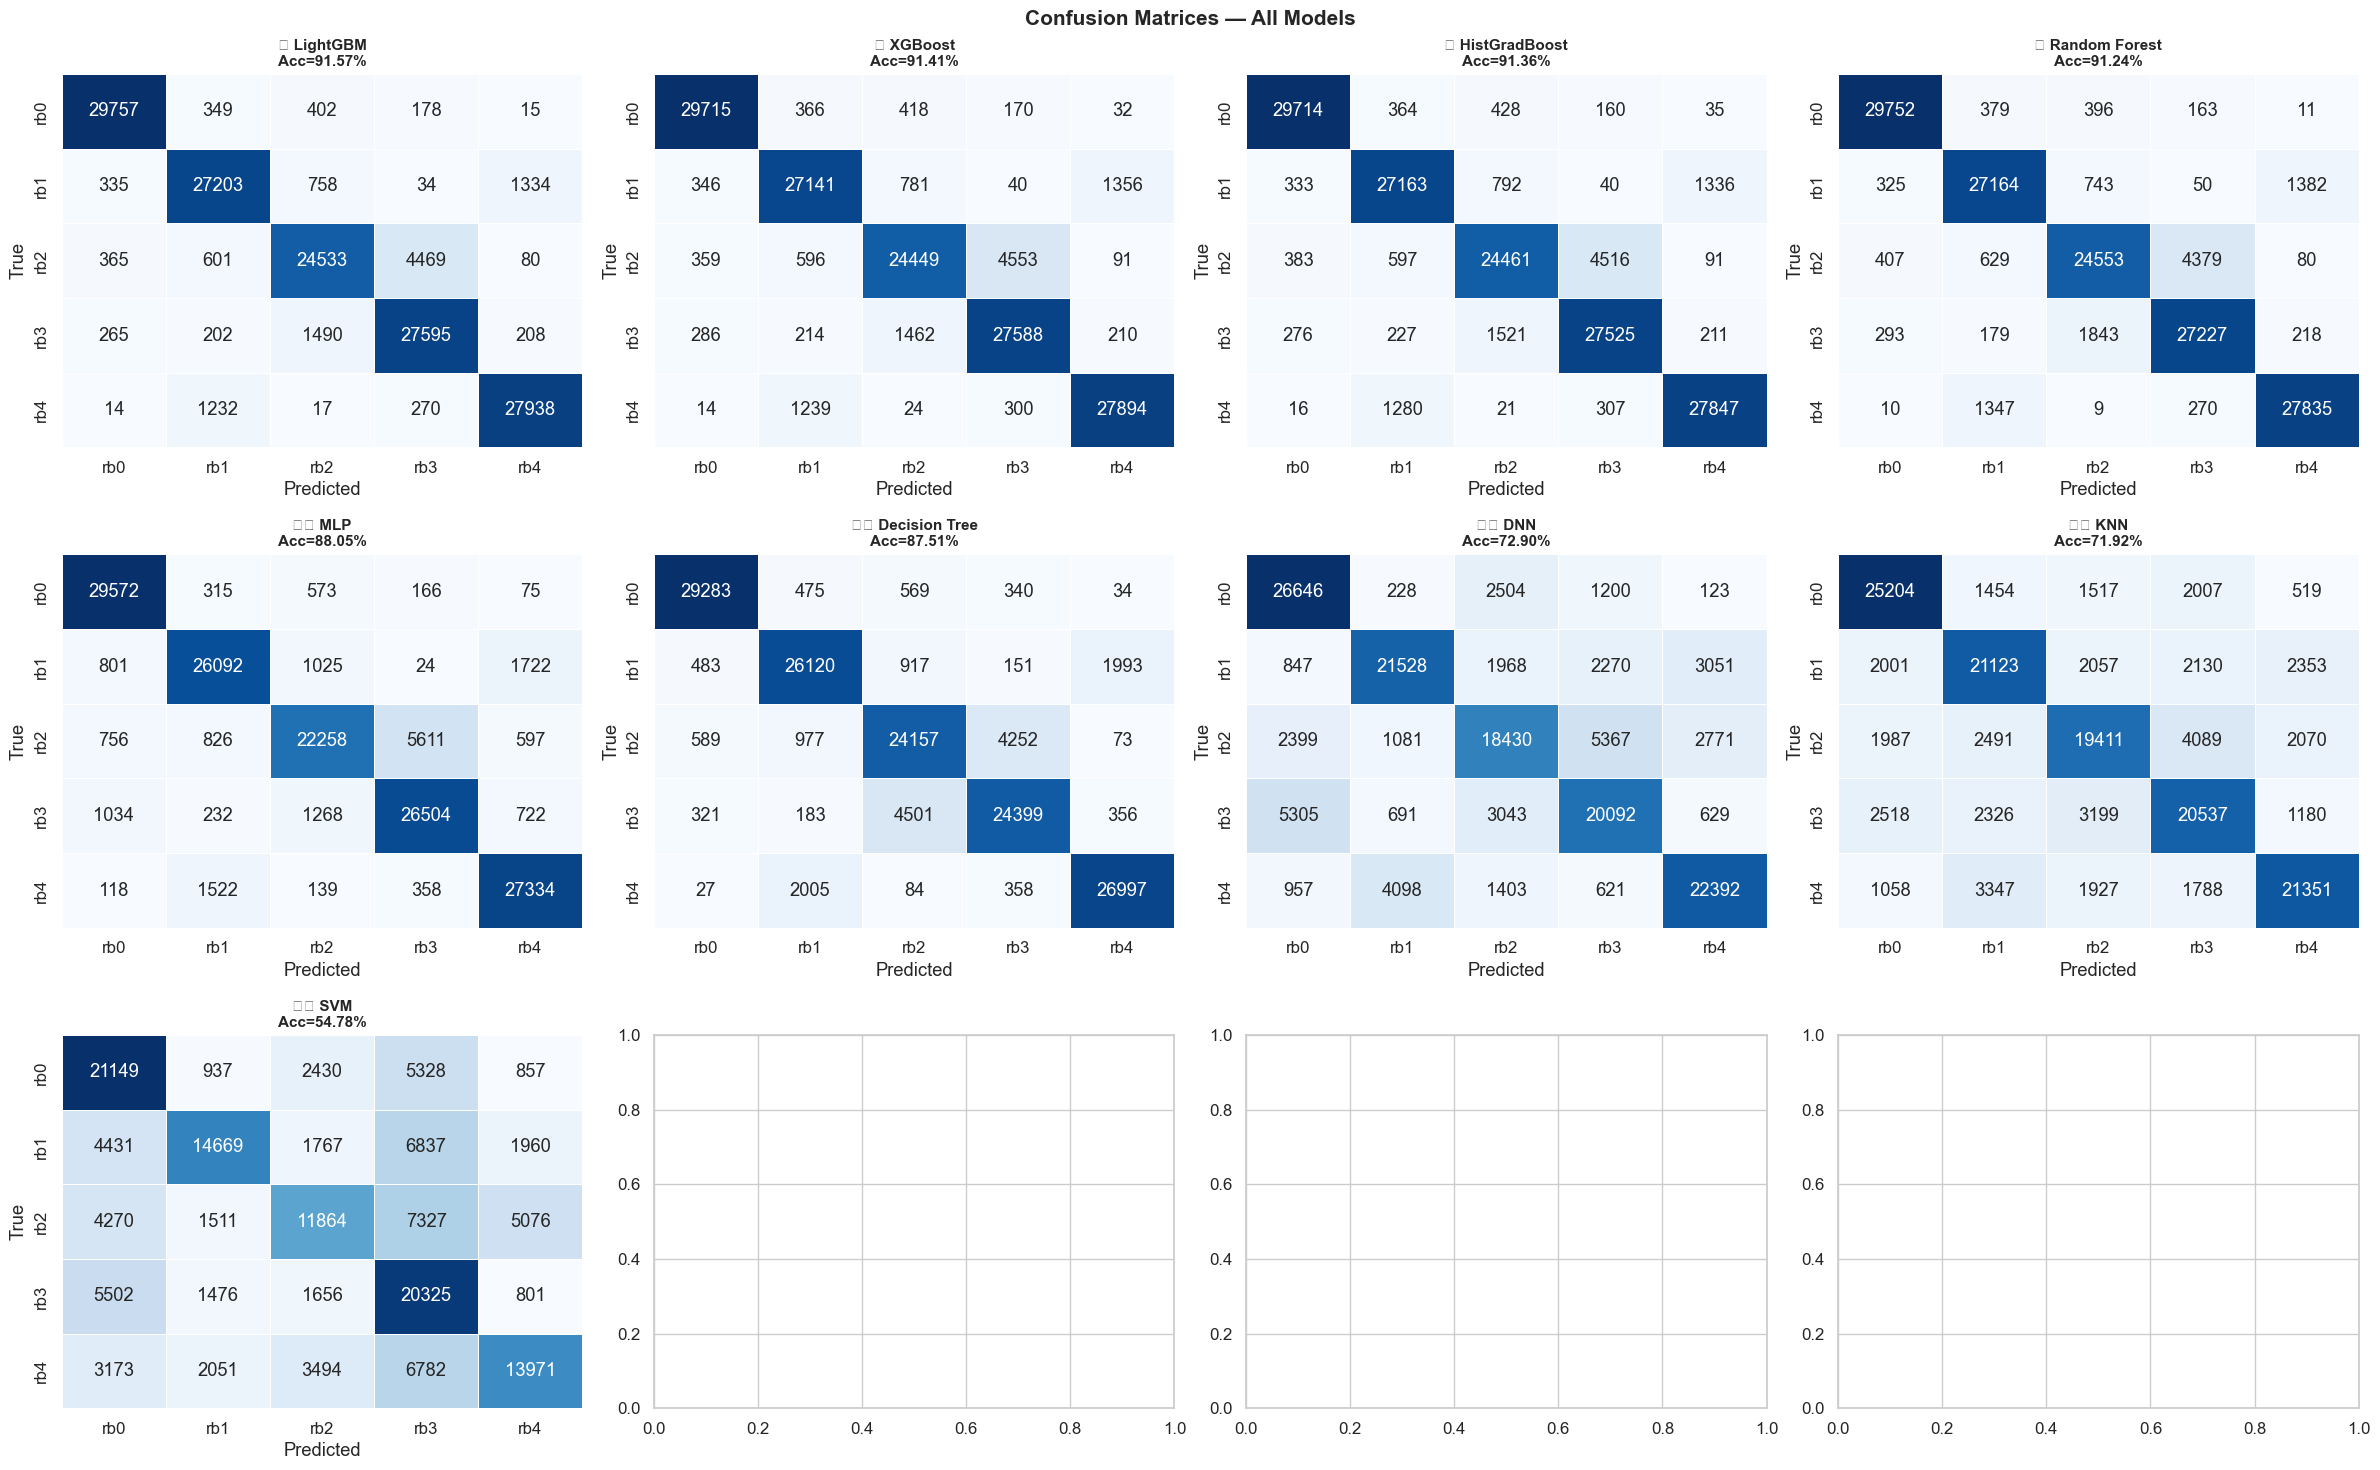

✅ Saved: 09_confusion_matrices.png


In [38]:
all_preds_cm = [(n, ml_preds[n]) for n in results_df.index]
ncols = 4; nrows = (len(all_preds_cm)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(6*ncols, 5*nrows), facecolor='white')
axes = axes.flat

for ax, (mname, yp) in zip(axes, all_preds_cm):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar=False)
    acc = RESULTS[mname]['Accuracy']
    flag = '✅' if acc >= 90 else '⚠️'
    ax.set_title(f'{flag} {mname}\nAcc={acc:.2f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

for ax in list(axes)[len(all_preds_cm):]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('09_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 09_confusion_matrices.png')

## § 13 · ROC-AUC Curves

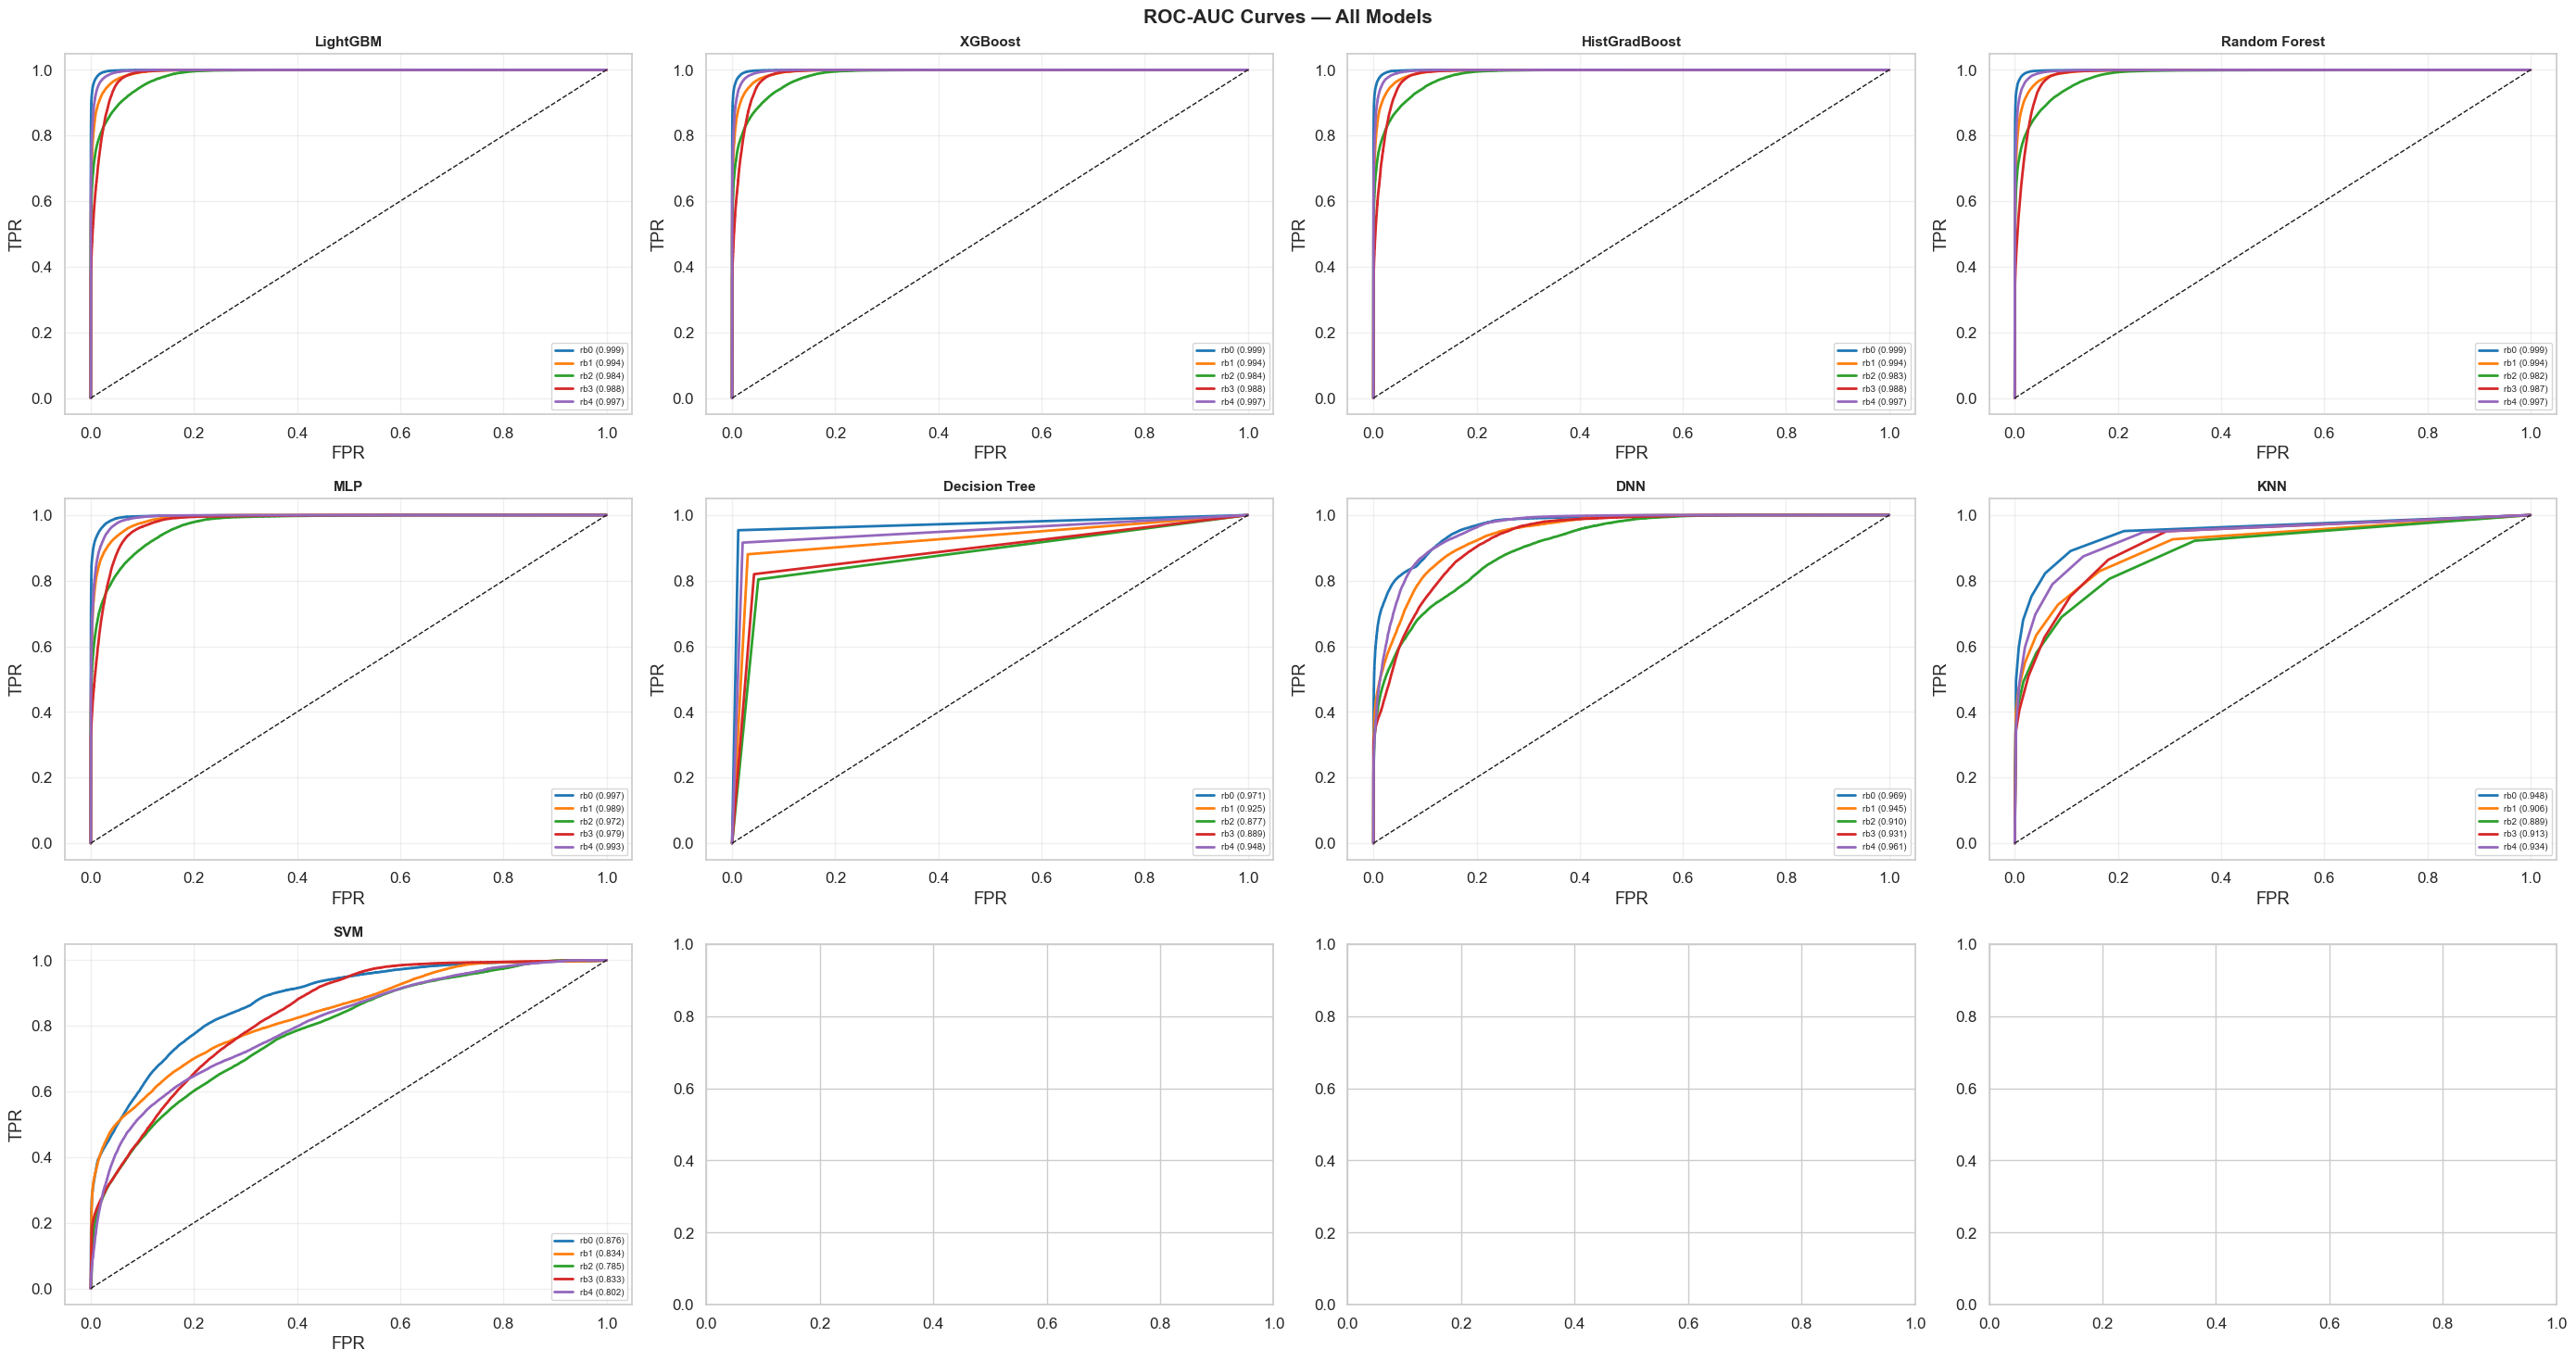

✅ Saved: 10_roc_curves.png


In [39]:
models_with_prob = [(n, ml_probs[n]) for n in results_df.index if ml_probs.get(n) is not None]
ncols = 4; nrows = (len(models_with_prob)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7*ncols, 5*nrows), facecolor='white')
axes = axes.flat
colors_roc = sns.color_palette('tab10', N_CLASSES)

for ax, (mname, prob) in zip(axes, models_with_prob):
    if prob is None or prob.ndim == 1:
        ax.set_visible(False); continue
    if prob.shape[1] != N_CLASSES:
        ax.set_visible(False); continue
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_cat[:,i], prob[:,i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} ({roc_auc_val:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'{mname}', fontweight='bold', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

for ax in list(axes)[len(models_with_prob):]:
    ax.set_visible(False)

plt.suptitle('ROC-AUC Curves — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('10_roc_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 10_roc_curves.png')

## § 14 · Feature Importance (RF & LightGBM)

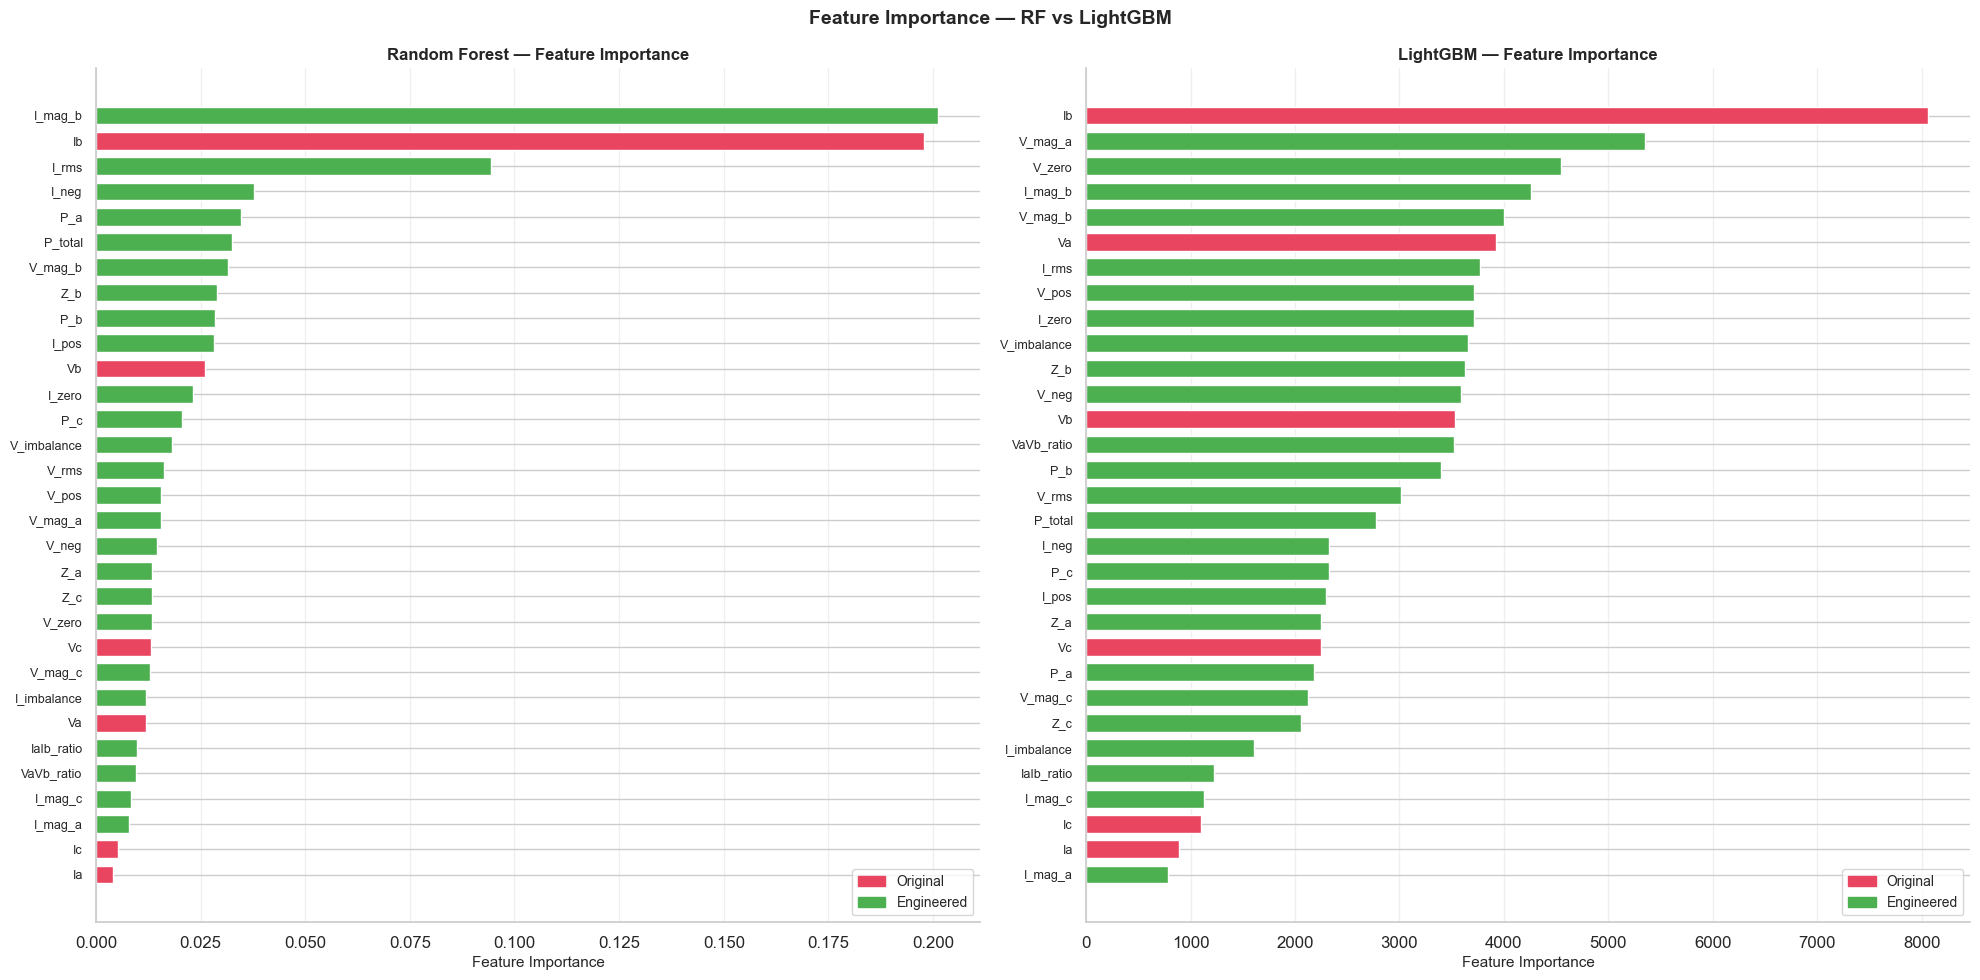

✅ Saved: 11_feature_importance.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')
for ax, mname in zip(axes, ['Random Forest', 'LightGBM']):
    model_fi = ml_models[mname]
    fi = pd.Series(model_fi.feature_importances_, index=ALL_FEATS).sort_values(ascending=True)
    colors_fi = ['#E94560' if f in FEATURES else '#4CAF50' for f in fi.index]
    ax.barh(range(N_FEATS), fi.values, color=colors_fi, edgecolor='white', height=0.7)
    ax.set_yticks(range(N_FEATS))
    ax.set_yticklabels(fi.index, fontsize=9)
    ax.set_xlabel('Feature Importance', fontsize=11)
    ax.set_title(f'{mname} — Feature Importance', fontweight='bold', fontsize=12)
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    legend_els = [mpatches.Patch(color='#E94560', label='Original'),
                  mpatches.Patch(color='#4CAF50', label='Engineered')]
    ax.legend(handles=legend_els, fontsize=10)

plt.suptitle('Feature Importance — RF vs LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 11_feature_importance.png')

<h2 style='padding:12px 20px;color:white;background:linear-gradient(90deg,#0f3460,#16213e,#e94560);border-radius:8px;border-left:5px solid #ffeb3b;'>🔍 Explainable AI (XAI) — SHAP · LIME  (Paderborn-style Histogram + Cylindrical LIME)</h2>

<p style='padding:10px 18px;background:#E3F2FD;border-radius:8px;border-left:4px solid #1976D2;font-size:14px'>
<b>SHAP</b>: TreeExplainer (DT/RF/XGB/LGBM/HGB) · GradientExplainer (DNN) · KernelExplainer (SVM/KNN/MLP)<br>
<b>LIME</b>: Cylindrical 3D bar charts — all 9 models × all classes (Paderborn § 13 identical style)
</p>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 1 — Setup: confirm registries, LIME explainers, colour palette
#
# Variable audit — exact names from previously executed cells:
#   ml_models dict  → Cell[24] evaluate_model()
#     ALL 8 models  → X_train_sm / X_test_sc  (SMOTE-scaled)
#   dnn             → Cell[47]: input X_dl_tr/X_test_sc (2D: N, N_FEATS)
#   NOTE: cnn1d referenced in Cell[70] but cells [48][49] are empty
#         → only dnn is used for DL SHAP/LIME
#   X_train_sm      → Cell[21]: SMOTE-resampled StandardScaler train
#   X_test_sc       → Cell[21]: StandardScaler test
#   X_dl_tr         → Cell[21]: DL train split from X_train_sm
#   ALL_FEATS       → Cell[18]: all 29 engineered feature names
#   N_FEATS         → Cell[18]: len(ALL_FEATS)
#   CLASS_NAMES     → Cell[21]: le.classes_ (numpy array)
#   N_CLASSES       → Cell[21]: len(CLASS_NAMES)
#   y_test          → Cell[21]: encoded test labels
#   X_shap_bg       → Cell[62]: 300 stratified bg samples from X_train_sm
# ══════════════════════════════════════════════════════════════════════════
import shap, lime, lime.lime_tabular
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

# ── Confirm ml_models registry ────────────────────────────────────────────
print("ML models in registry:", list(ml_models.keys()))

# ── Model key groups ──────────────────────────────────────────────────────
tree_model_keys = ['Decision Tree', 'Random Forest', 'XGBoost',
                   'LightGBM', 'HistGradBoost']
sc_model_keys   = ['SVM', 'KNN', 'MLP']

# ── K_FEATS for histogram display ─────────────────────────────────────────
K_FEATS_SHAP = min(15, N_FEATS)

# ── LIME explainers ───────────────────────────────────────────────────────
# All models trained on X_train_sm (already scaled) — use same for both
lime_exp_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data     = X_train_sm,
    feature_names     = ALL_FEATS,
    class_names       = CLASS_NAMES.tolist(),
    mode              = 'classification',
    discretize_continuous = True,
    random_state      = 42)

lime_exp_sc = lime.lime_tabular.LimeTabularExplainer(
    training_data     = X_train_sm,
    feature_names     = ALL_FEATS,
    class_names       = CLASS_NAMES.tolist(),
    mode              = 'classification',
    discretize_continuous = True,
    random_state      = 42)

# ── Colour palette ────────────────────────────────────────────────────────
hdr_colors_xai = ['#1976D2','#F57C00','#2E7D32','#7B1FA2',
                   '#C62828','#0097A7'][:N_CLASSES]

# ── SHAP background (reuse if Cell[62] was run, else create) ─────────────
if 'X_shap_bg' not in dir():
    from sklearn.model_selection import StratifiedShuffleSplit
    sss_bg = StratifiedShuffleSplit(n_splits=1,
                 test_size=min(300, len(X_train_sm)-1)/len(X_train_sm),
                 random_state=42)
    _, bg_idx = next(sss_bg.split(X_train_sm, y_train_sm))
    X_shap_bg = X_train_sm[bg_idx]

print(f"\nXAI setup complete")
print(f"  Tree models     : {tree_model_keys}")
print(f"  Kernel models   : {sc_model_keys}")
print(f"  DL model        : dnn  (input: X_test_sc, 2D: N, {N_FEATS})")
print(f"  ALL_FEATS       : {N_FEATS}  |  CLASS_NAMES: {CLASS_NAMES.tolist()}")
print(f"  X_train_sm      : {X_train_sm.shape}  |  X_test_sc: {X_test_sc.shape}")
print(f"  X_shap_bg       : {X_shap_bg.shape}")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 2 — SHAP helper functions (Paderborn histogram style)
# Uses: N_CLASSES, ALL_FEATS, K_FEATS_SHAP, CLASS_NAMES, hdr_colors_xai
# ══════════════════════════════════════════════════════════════════════════

def get_shap_values(model_name, model, X_data):
    """Return shap_list: one (n_samples, n_feats) array per class."""
    if model_name == 'XGBoost':
        explainer   = shap.Explainer(model, X_data)
        shap_values = explainer(X_data)
        sv = shap_values.values
        if sv.ndim == 3:
            return [sv[:, :, i] for i in range(N_CLASSES)]
        else:
            return [sv]
    else:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_data)
        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            return [shap_values[:, :, i] for i in range(N_CLASSES)]
        elif isinstance(shap_values, list):
            return shap_values
        else:
            return [shap_values]


def plot_shap_global(shap_list, model_name, feat_list, palette='viridis'):
    """Global SHAP histogram — Paderborn presentation style."""
    k          = min(K_FEATS_SHAP, len(feat_list))
    shap_agg   = np.mean(np.abs(np.array(shap_list)), axis=0)
    mean_shap  = np.mean(np.abs(shap_agg), axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1][:k]
    s_feats    = [feat_list[i] for i in sorted_idx]
    s_vals     = mean_shap[sorted_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#FAFAFA')
    colors = sns.color_palette(palette, len(s_feats))
    bars   = ax.barh(s_feats[::-1], s_vals[::-1],
                     color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, s_vals[::-1]):
        ax.text(bar.get_width() + mean_shap.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value| — Global Feature Importance', fontsize=11)
    ax.set_title(f'SHAP Global Histogram — {model_name}',
                 fontsize=13, fontweight='bold', color='#0f3460')
    ax.set_xlim(0, mean_shap.max()*1.22 if mean_shap.max() > 0 else 1)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'shap_global_{model_name.replace(" ","_").replace("-","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show(); print(f'  Saved: {fname}')


def plot_shap_perclass(shap_list, model_name, feat_list, top_k=12):
    """Per-class SHAP histograms — Paderborn presentation style."""
    n_cls = len(shap_list)
    fig, axes = plt.subplots(1, n_cls, figsize=(7*n_cls, 6))
    if n_cls == 1: axes = [axes]
    fig.patch.set_facecolor('#FAFAFA')
    for cls_id, ax in enumerate(axes):
        mean_abs = np.mean(np.abs(shap_list[cls_id]), axis=0)
        si       = np.argsort(mean_abs)[-min(top_k, len(feat_list)):]
        bc       = sns.color_palette('Set2', len(si))
        bars     = ax.barh([feat_list[i] for i in si],
                           mean_abs[si], color=bc, edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, mean_abs[si]):
            mx = mean_abs[si].max()
            ax.text(bar.get_width() + mx*0.015,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')
        lbl = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'Class {cls_id}'
        ax.set_title(f'Class: {lbl}', fontweight='bold', fontsize=12,
                     color=hdr_colors_xai[cls_id % len(hdr_colors_xai)])
        ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
        mx = mean_abs[si].max() if mean_abs[si].max() > 0 else 1
        ax.set_xlim(0, mx*1.22)
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.suptitle(f'SHAP Per-Class Histogram — {model_name}',
                 fontsize=13, fontweight='bold', color='#0f3460', y=1.02)
    plt.tight_layout()
    fname = f'shap_perclass_{model_name.replace(" ","_").replace("-","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show(); print(f'  Saved: {fname}')

print("SHAP helpers ready: get_shap_values, plot_shap_global, plot_shap_perclass")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 3 — SHAP TreeExplainer:
#   Decision Tree, Random Forest, XGBoost, LightGBM, HistGradBoost
#   All trained on X_train_sm → SHAP on X_test_sc
#   ml_models dict built by evaluate_model() in Cell[24]
# ══════════════════════════════════════════════════════════════════════════

for model_name in tree_model_keys:
    print('=' * 55)
    print(f'Computing SHAP TreeExplainer: {model_name}')
    print('=' * 55)
    try:
        shap_list = get_shap_values(model_name, ml_models[model_name], X_test_sc)
        print(f'  Classes    : {len(shap_list)}')
        print(f'  Shape/class: {shap_list[0].shape}')
        plot_shap_global(shap_list, model_name, ALL_FEATS, palette='viridis')
        plot_shap_perclass(shap_list, model_name, ALL_FEATS)
        print(f'  {model_name} DONE')
    except Exception as e:
        print(f'  ERROR for {model_name}: {e}')
    print()

print('=' * 55)
print('ALL TREE MODEL SHAP COMPLETE')
print('=' * 55)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 4 — SHAP GradientExplainer: DNN
#   dnn → trained in Cell[47]: input (N, N_FEATS), trained on X_dl_tr
#   NOTE: cnn1d is referenced in Cell[70] but was NOT trained
#         (cells [48][49] are empty) — only dnn is used here
# ══════════════════════════════════════════════════════════════════════════

# Background (100) and test (200) subsets
bg_idx  = np.random.choice(len(X_dl_tr), min(100, len(X_dl_tr)), replace=False)
te_idx  = np.random.choice(len(X_test_sc), min(200, len(X_test_sc)), replace=False)
bg_2d   = X_dl_tr[bg_idx]        # (100, N_FEATS)  — DNN train data
te_2d   = X_test_sc[te_idx]      # (200, N_FEATS)  — test data

print('=' * 55)
print(f'SHAP GradientExplainer: DNN  (2D: N, {N_FEATS})')
print('=' * 55)
try:
    exp_dnn = shap.GradientExplainer(dnn, bg_2d)
    sv_dnn  = exp_dnn.shap_values(te_2d)

    # Normalise to list of (n_samples, n_feats)
    if isinstance(sv_dnn, list):
        sl_dnn = [np.array(sv).reshape(np.array(sv).shape[0], -1) for sv in sv_dnn]
    else:
        sv_arr = np.array(sv_dnn).reshape(np.array(sv_dnn).shape[0], -1)
        sl_dnn = [sv_arr]

    print(f'  Classes    : {len(sl_dnn)}')
    print(f'  Shape/class: {sl_dnn[0].shape}')
    plot_shap_global(sl_dnn, 'DNN', ALL_FEATS, palette='magma')
    plot_shap_perclass(sl_dnn, 'DNN', ALL_FEATS)

    # Beeswarm per class
    for cls_id in range(len(sl_dnn)):
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sl_dnn[cls_id], te_2d,
                          feature_names=ALL_FEATS,
                          max_display=15, plot_type='dot', show=False)
        lbl = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'Class {cls_id}'
        plt.title(f'SHAP Beeswarm — DNN — Class: {lbl}',
                  fontsize=12, fontweight='bold', color='#0f3460')
        plt.tight_layout()
        fname = f'shap_beeswarm_DNN_cls{cls_id}.png'
        plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
        print(f'  Saved: {fname}')
    print('  DNN DONE')

except Exception as e:
    print(f'  GradientExplainer failed for DNN: {e}')
    print('  Falling back to KernelExplainer for DNN...')
    try:
        pred_fn_dnn = lambda X: dnn.predict(X, verbose=0)
        exp_k       = shap.KernelExplainer(pred_fn_dnn, bg_2d[:30])
        sv_k        = exp_k.shap_values(te_2d[:20], nsamples=100)
        sl_k        = sv_k if isinstance(sv_k, list) else [sv_k]
        plot_shap_global(sl_k, 'DNN (Kernel)', ALL_FEATS, palette='magma')
        plot_shap_perclass(sl_k, 'DNN (Kernel)', ALL_FEATS)
    except Exception as e2:
        print(f'  DNN fallback also failed: {e2}')
print()
print('=' * 55)
print('DL MODEL SHAP COMPLETE')
print('=' * 55)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 5 — SHAP KernelExplainer: SVM, KNN, MLP
#   All trained on X_train_sm / X_test_sc (SMOTE-scaled)
#   ml_models dict from Cell[24] via evaluate_model()
# ══════════════════════════════════════════════════════════════════════════

# Background (100) and test (50) — KernelExplainer is slow
bg_k = X_train_sm[np.random.choice(len(X_train_sm), min(100, len(X_train_sm)), replace=False)]
te_k = X_test_sc[np.random.choice(len(X_test_sc),   min(50,  len(X_test_sc)),  replace=False)]

for model_name in sc_model_keys:
    print('=' * 55)
    print(f'Computing SHAP KernelExplainer: {model_name}  (may take 2–5 min)')
    print('=' * 55)
    try:
        explainer   = shap.KernelExplainer(
            lambda X: ml_models[model_name].predict_proba(X), bg_k)
        shap_values = explainer.shap_values(te_k, nsamples=200)

        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_list = [shap_values[:, :, i] for i in range(N_CLASSES)]
        elif isinstance(shap_values, list):
            shap_list = shap_values
        else:
            shap_list = [shap_values]

        print(f'  Shape per class: {shap_list[0].shape}')
        plot_shap_global(shap_list,  model_name, ALL_FEATS, palette='plasma')
        plot_shap_perclass(shap_list, model_name, ALL_FEATS)
        print(f'  {model_name} DONE')
    except Exception as e:
        print(f'  ERROR for {model_name}: {e}')
    print()

print('Kernel model SHAP done')


<h2 style='padding:10px 18px;color:white;background:linear-gradient(90deg,#e94560,#0f3460);border-radius:8px'>🧊 LIME — Cylindrical 3D Bar Charts (Paderborn § 13 Style)</h2>

<p style='padding:8px 16px;background:#FFF3E0;border-radius:8px;border-left:4px solid #F57C00;font-size:13px'>
Cylindrical 3D LIME bars — all 9 models × all classes.
</p>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 6 — Cylindrical 3D LIME bar chart function (Paderborn § 13 style)
# ══════════════════════════════════════════════════════════════════════════

def plot_lime_cylinder(feats, weights, pred_label, model_name,
                       class_name, num_features=8, save_path=None):
    feats   = feats[:num_features]
    weights = weights[:num_features]
    POS_COLORS = [('#1E88E5','#64B5F6','#0D47A1'),
                  ('#00ACC1','#4DD0E1','#006064'),
                  ('#43A047','#81C784','#1B5E20'),
                  ('#7B1FA2','#CE93D8','#4A148C'),
                  ('#F57C00','#FFB74D','#E65100'),
                  ('#00897B','#80CBC4','#00695C'),
                  ('#3949AB','#9FA8DA','#283593'),
                  ('#D81B60','#F48FB1','#AD1457')]
    NEG_FACE, NEG_LITE, NEG_DARK = '#E53935', '#EF9A9A', '#B71C1C'
    BAR_W, DEPTH, ELIP_H = 0.55, 0.20, 0.35
    max_h = max(abs(w) for w in weights) if weights else 0.01

    fig, ax = plt.subplots(figsize=(max(12, num_features*1.6), 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#FAFAFA')

    for i, (feat, w) in enumerate(zip(feats, weights)):
        x = float(i); h = abs(w); pos = (w >= 0)
        fc, lc, dc = (POS_COLORS[i % len(POS_COLORS)] if pos
                      else (NEG_FACE, NEG_LITE, NEG_DARK))
        y_bot = 0.0 if pos else -h
        y_top = h   if pos else  0.0

        ax.add_patch(plt.Polygon(
            [[x+BAR_W/2,y_bot],[x+BAR_W/2+DEPTH,y_bot-DEPTH],
             [x+BAR_W/2+DEPTH,y_top-DEPTH],[x+BAR_W/2,y_top]],
            facecolor=dc, edgecolor='none', alpha=0.75, zorder=2))
        ax.add_patch(plt.Polygon(
            [[x-BAR_W/2,y_bot],[x+BAR_W/2,y_bot],
             [x+BAR_W/2+DEPTH,y_bot-DEPTH],[x-BAR_W/2+DEPTH,y_bot-DEPTH]],
            facecolor=dc, edgecolor='none', alpha=0.5, zorder=2))
        ax.add_patch(plt.Rectangle((x-BAR_W/2,y_bot), BAR_W, h,
            facecolor=fc, edgecolor='none', zorder=3))
        ax.add_patch(plt.Rectangle((x-BAR_W/2,y_bot), BAR_W*0.18, h,
            facecolor=lc, edgecolor='none', alpha=0.65, zorder=5))
        ax.add_patch(Ellipse((x+DEPTH/2, y_bot-DEPTH/2),
            width=BAR_W, height=BAR_W*ELIP_H,
            facecolor=dc, edgecolor='none', alpha=0.65, zorder=2))
        ax.add_patch(Ellipse((x+DEPTH/2, y_top-DEPTH/2),
            width=BAR_W, height=BAR_W*ELIP_H,
            facecolor=lc, edgecolor='white', linewidth=1.4, zorder=4))

        sign_str = f'+{w:.4f}' if w > 0 else f'{w:.4f}'
        ax.text(x+DEPTH/2, y_top+max_h*0.08, sign_str,
                ha='center', va='bottom', fontsize=9.5,
                fontweight='bold', color='#212121', zorder=6)
        short = feat if len(feat) <= 18 else feat[:16]+'..'
        ax.text(x+DEPTH/2, -max_h*1.08, short,
                ha='center', va='top', fontsize=8,
                color='#1565C0' if pos else '#C62828',
                style='italic', zorder=6, rotation=22, rotation_mode='anchor')

    ax.axhline(0, color='#9E9E9E', linewidth=1.5, zorder=1)
    for yg in np.linspace(-max_h, max_h, 6):
        ax.axhline(yg, color='#E0E0E0', linewidth=0.7, zorder=0)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xlim(-0.7, len(feats)-0.2+DEPTH)
    ax.set_ylim(-max_h*1.7, max_h*1.3)
    ax.legend(handles=[
        mpatches.Patch(facecolor='#1E88E5', edgecolor='#0D47A1',
                       linewidth=1.5, label='Supports (+)'),
        mpatches.Patch(facecolor='#E53935', edgecolor='#B71C1C',
                       linewidth=1.5, label='Against  (-)'),
    ], loc='upper right', fontsize=10, frameon=True, framealpha=0.95, facecolor='white')
    ax.text(0.01, 0.99, f'Predicted: {pred_label}',
            transform=ax.transAxes, fontsize=10, va='top', color='#0f3460',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='#1565C0'))
    ax.set_title(
        f'LIME — Predicted: {pred_label} | {model_name} | True: {class_name} | Top {num_features} Features',
        fontsize=12, fontweight='bold', pad=14, color='#0f3460')
    plt.tight_layout(pad=2.2)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close()

print("Cylindrical LIME function ready")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 7 — LIME Cylindrical: ALL 8 ML models × ALL classes
#   All 8 ML models trained on X_train_sm / X_test_sc  (SMOTE-scaled)
#   lime_exp_raw used for tree models, lime_exp_sc for SVM/KNN/MLP
#   Both explainers built on X_train_sm (already scaled after SMOTE)
#   ml_models dict from Cell[24]
# ══════════════════════════════════════════════════════════════════════════

models_lime_ml = [
    # (name, predict_fn, lime_explainer, X_test_local)
    ('Decision Tree',
     lambda X: ml_models['Decision Tree'].predict_proba(X), lime_exp_raw, X_test_sc),
    ('Random Forest',
     lambda X: ml_models['Random Forest'].predict_proba(X), lime_exp_raw, X_test_sc),
    ('XGBoost',
     lambda X: ml_models['XGBoost'].predict_proba(X),       lime_exp_raw, X_test_sc),
    ('LightGBM',
     lambda X: ml_models['LightGBM'].predict_proba(X),      lime_exp_raw, X_test_sc),
    ('HistGradBoost',
     lambda X: ml_models['HistGradBoost'].predict_proba(X), lime_exp_raw, X_test_sc),
    ('SVM',
     lambda X: ml_models['SVM'].predict_proba(X),           lime_exp_sc,  X_test_sc),
    ('KNN',
     lambda X: ml_models['KNN'].predict_proba(X),           lime_exp_sc,  X_test_sc),
    ('MLP',
     lambda X: ml_models['MLP'].predict_proba(X),           lime_exp_sc,  X_test_sc),
]

for cls_id in sorted(np.unique(y_test)):
    correct = np.where(y_test == cls_id)[0]
    if len(correct) == 0:
        print(f'  No test samples for class {CLASS_NAMES[cls_id]}, skipping'); continue
    idx = correct[0]
    print()
    print('=' * 60)
    print(f'  Class: {CLASS_NAMES[cls_id]}  |  Sample Index: {idx}')
    print('=' * 60)

    for mname, pred_fn, exp_obj, Xte_local in models_lime_ml:
        instance = Xte_local[idx]
        try:
            exp       = exp_obj.explain_instance(instance, pred_fn,
                            num_features=8, num_samples=400, top_labels=1)
            label     = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats     = [fv[0] for fv in feat_vals]
            weights   = [fv[1] for fv in feat_vals]
            prob      = pred_fn(instance.reshape(1, -1))[0]
            pred_lbl  = CLASS_NAMES[int(np.argmax(prob))]
            flag      = '✅' if pred_lbl == CLASS_NAMES[cls_id] else '❌'
            print(f'  {flag} {mname:<20} -> {pred_lbl}')
            fname = f'lime_cyl_{CLASS_NAMES[cls_id].replace(" ","_")}_{mname.replace(" ","_")}.png'
            plot_lime_cylinder(feats, weights, pred_lbl, mname,
                               CLASS_NAMES[cls_id], num_features=8, save_path=fname)
        except Exception as e:
            print(f'  ⚠️ {mname:<20} error: {str(e)[:80]}')

print()
print('ALL ML MODEL LIME COMPLETE')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# XAI CELL 8 — LIME Cylindrical: DNN
#   dnn trained in Cell[47]: input (N, N_FEATS), data: X_dl_tr / X_test_sc
#   NOTE: cnn1d not trained (cells [48][49] are empty) — only dnn here
#   lime_exp_sc on X_train_sm (same scaled feature space as DNN input)
# ══════════════════════════════════════════════════════════════════════════

def pred_fn_dnn_lime(X):
    """DNN: (N, N_FEATS) → (N, N_CLASSES) softmax probabilities."""
    return dnn.predict(X, verbose=0)

# DNN uses scaled features → lime_exp_sc + X_test_sc
models_lime_dl = [
    ('DNN', pred_fn_dnn_lime, lime_exp_sc, X_test_sc),
]

for cls_id in sorted(np.unique(y_test)):
    correct = np.where(y_test == cls_id)[0]
    if len(correct) == 0:
        print(f'  No test samples for class {CLASS_NAMES[cls_id]}, skipping'); continue
    idx = correct[0]
    print()
    print('=' * 60)
    print(f'  Class: {CLASS_NAMES[cls_id]}  |  Sample Index: {idx}  (DL models)')
    print('=' * 60)

    for mname, pred_fn, exp_obj, Xte_local in models_lime_dl:
        instance = Xte_local[idx]
        try:
            exp       = exp_obj.explain_instance(instance, pred_fn,
                            num_features=8, num_samples=400, top_labels=1)
            label     = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats     = [fv[0] for fv in feat_vals]
            weights   = [fv[1] for fv in feat_vals]
            prob      = pred_fn(instance.reshape(1, -1))[0]
            pred_lbl  = CLASS_NAMES[int(np.argmax(prob))]
            flag      = '✅' if pred_lbl == CLASS_NAMES[cls_id] else '❌'
            print(f'  {flag} {mname:<20} -> {pred_lbl}')
            fname = f'lime_cyl_{CLASS_NAMES[cls_id].replace(" ","_")}_{mname.replace(" ","_")}.png'
            plot_lime_cylinder(feats, weights, pred_lbl, mname,
                               CLASS_NAMES[cls_id], num_features=8, save_path=fname)
        except Exception as e:
            print(f'  ⚠️ {mname:<20} error: {str(e)[:80]}')

print()
print('ALL DL MODEL LIME COMPLETE')
print('XAI SECTION FULLY DONE — SHAP + LIME')


## § 15 · Explainable AI — SHAP

In [ ]:
import shap
shap.initjs()

# Background: 300 stratified samples
sss_bg = StratifiedShuffleSplit(n_splits=1, test_size=300/len(X_train_sm), random_state=42)
_, bg_idx = next(sss_bg.split(X_train_sm, y_train_sm))
X_shap_bg  = X_train_sm[bg_idx]
X_shap_te  = X_test_sc

print(f'SHAP background: {X_shap_bg.shape}')
print(f'SHAP test set  : {X_shap_te.shape}')

In [ ]:
print('SHAP — All Models Global Importance...')

# ── Models to explain ─────────────────────────────────────────
# Tree models: TreeExplainer (fast, exact)
# DNN/CNN:     KernelExplainer (slower, model-agnostic)

tree_models = ['Decision Tree', 'Random Forest', 'XGBoost',
               'LightGBM', 'HistGradBoost']

all_shap_imp = {}   # stores mean |SHAP| per model for cross-model plot

# ══════════════════════════════════════════════════════════════
# PART 1: TREE MODELS — TreeExplainer
# ══════════════════════════════════════════════════════════════
for mname in tree_models:
    print(f'\n  Computing SHAP — {mname}...')
    try:
        explainer = shap.TreeExplainer(
            ml_models[mname],
            data=X_shap_bg,
            feature_perturbation='interventional')
        shap_exp  = explainer(X_shap_te)
        sv        = shap_exp.values   # (N, features) or (N, features, classes)

        # Handle multi-class (3D)
        if sv.ndim == 3:
            sv_mean = np.abs(sv).mean(axis=2)   # (N, features)
            shap_2d = shap.Explanation(
                values        = shap_exp.values[:, :, 1],
                base_values   = shap_exp.base_values[:, 1],
                data          = shap_exp.data,
                feature_names = ALL_FEATS)
        else:
            sv_mean = np.abs(sv)
            shap_2d = shap_exp

        mean_abs = pd.Series(sv_mean.mean(axis=0),
                             index=ALL_FEATS).sort_values(ascending=False)
        all_shap_imp[mname] = mean_abs

        # ── Individual plot: bar + beeswarm ──────────────────
        top_n = min(20, N_FEATS)
        top_s = mean_abs.head(top_n)

        fig, axes = plt.subplots(1, 2, figsize=(24, 9), facecolor='white')

        ax = axes[0]
        colors_s = ['#E94560' if f in FEATURES else '#4CAF50'
                    for f in top_s.index]
        ax.barh(range(top_n), top_s.values[::-1],
                color=colors_s[::-1], edgecolor='white', height=0.7)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_s.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP value| (avg across classes)', fontsize=11)
        ax.set_title(f'{mname} — Global Feature Importance (SHAP)\nTop {top_n}',
                     fontweight='bold', fontsize=12)
        ax.grid(True, axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        legend_els = [
            mpatches.Patch(color='#E94560', label='Original features'),
            mpatches.Patch(color='#4CAF50', label='Engineered features')]
        ax.legend(handles=legend_els, loc='lower right', fontsize=9)

        plt.sca(axes[1])
        shap.plots.beeswarm(shap_2d, max_display=top_n, show=False)
        axes[1].set_title(
            f'SHAP Beeswarm — {mname} (class: {CLASS_NAMES[1]})',
            fontweight='bold', fontsize=12)

        plt.suptitle(f'SHAP Global Explainability — {mname} | Electrical Fault',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f'shap_{mname.replace(" ","_")}_global.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f'  ✅ Saved: {fname}')

    except Exception as e:
        print(f'  ⚠️ {mname} SHAP error: {e}')


# ══════════════════════════════════════════════════════════════
# PART 2: SVM, KNN, MLP — KernelExplainer
# ══════════════════════════════════════════════════════════════
kernel_models = {
    'SVM': lambda X: ml_models['SVM'].predict_proba(X),
    'KNN': lambda X: ml_models['KNN'].predict_proba(X),
    'MLP': lambda X: ml_models['MLP'].predict_proba(X),
}

bg_km = shap.kmeans(X_shap_bg, 20)   # k-means summary for KernelExplainer

for mname, pred_fn in kernel_models.items():
    print(f'\n  Computing SHAP — {mname} (KernelExplainer)...')
    try:
        exp_kernel = shap.KernelExplainer(pred_fn, bg_km)

        # Explain 100 test samples (balanced)
        n_each = min(20, sum(y_test == 0))
        sample_idx = []
        for c in sorted(np.unique(y_test)):
            sample_idx.extend(np.where(y_test == c)[0][:n_each])
        sample_idx = np.array(sample_idx)

        sv_kernel = exp_kernel.shap_values(
            X_shap_te[sample_idx], nsamples=100, silent=True)

        # sv_kernel is list of arrays (one per class) for multi-class
        if isinstance(sv_kernel, list):
            sv_stack = np.stack(sv_kernel, axis=2)   # (N, features, classes)
            sv_mean  = np.abs(sv_stack).mean(axis=2)
            sv_cls1  = sv_kernel[1]
        else:
            sv_mean = np.abs(sv_kernel)
            sv_cls1 = sv_kernel

        mean_abs = pd.Series(sv_mean.mean(axis=0),
                             index=ALL_FEATS).sort_values(ascending=False)
        all_shap_imp[mname] = mean_abs

        top_n = min(20, N_FEATS)
        top_s = mean_abs.head(top_n)

        fig, ax = plt.subplots(figsize=(14, 9), facecolor='white')
        colors_s = ['#E94560' if f in FEATURES else '#4CAF50'
                    for f in top_s.index]
        ax.barh(range(top_n), top_s.values[::-1],
                color=colors_s[::-1], edgecolor='white', height=0.7)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_s.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP value|', fontsize=11)
        ax.set_title(
            f'{mname} — Global Feature Importance (SHAP KernelExplainer)\nTop {top_n}',
            fontweight='bold', fontsize=13)
        ax.grid(True, axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        legend_els = [
            mpatches.Patch(color='#E94560', label='Original features'),
            mpatches.Patch(color='#4CAF50', label='Engineered features')]
        ax.legend(handles=legend_els, fontsize=10)
        plt.tight_layout()
        fname = f'shap_{mname}_global.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f'  ✅ Saved: {fname}')

    except Exception as e:
        print(f'  ⚠️ {mname} SHAP error: {e}')


# ══════════════════════════════════════════════════════════════
# PART 3: DNN — KernelExplainer
# ══════════════════════════════════════════════════════════════
print('\n  Computing SHAP — DNN (KernelExplainer)...')
try:
    def dnn_pred_fn(X): return dnn.predict(X, verbose=0)

    exp_dnn  = shap.KernelExplainer(dnn_pred_fn, bg_km)
    sv_dnn   = exp_dnn.shap_values(
        X_shap_te[sample_idx], nsamples=100, silent=True)

    if isinstance(sv_dnn, list):
        sv_dnn_mean = np.abs(np.stack(sv_dnn, axis=2)).mean(axis=2)
    else:
        sv_dnn_mean = np.abs(sv_dnn)

    mean_abs_dnn = pd.Series(sv_dnn_mean.mean(axis=0),
                              index=ALL_FEATS).sort_values(ascending=False)
    all_shap_imp['DNN'] = mean_abs_dnn

    top_n = min(20, N_FEATS)
    top_s = mean_abs_dnn.head(top_n)

    fig, ax = plt.subplots(figsize=(14, 9), facecolor='white')
    colors_s = ['#E94560' if f in FEATURES else '#4CAF50'
                for f in top_s.index]
    ax.barh(range(top_n), top_s.values[::-1],
            color=colors_s[::-1], edgecolor='white', height=0.7)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_s.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('DNN — Global Feature Importance (SHAP KernelExplainer)\n'
                 f'Top {top_n}', fontweight='bold', fontsize=13)
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend_els = [
        mpatches.Patch(color='#E94560', label='Original features'),
        mpatches.Patch(color='#4CAF50', label='Engineered features')]
    ax.legend(handles=legend_els, fontsize=10)
    plt.tight_layout()
    plt.savefig('shap_DNN_global.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print('  ✅ Saved: shap_DNN_global.png')

except Exception as e:
    print(f'  ⚠️ DNN SHAP error: {e}')


# ══════════════════════════════════════════════════════════════
# PART 4: CROSS-MODEL COMPARISON — all models side by side
# ══════════════════════════════════════════════════════════════
print('\n  Plotting cross-model SHAP comparison...')

if len(all_shap_imp) >= 2:
    def norm01(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-12)

    # Build comparison dataframe
    cmp_df = pd.DataFrame(
        {m: norm01(s) for m, s in all_shap_imp.items()},
        index=ALL_FEATS)
    cmp_df['Mean'] = cmp_df.mean(axis=1)
    cmp_df = cmp_df.sort_values('Mean', ascending=False).head(min(20, N_FEATS))

    n_models_shap = len(all_shap_imp)
    x  = np.arange(len(cmp_df))
    w  = 0.8 / n_models_shap
    model_colors_shap = sns.color_palette('tab10', n_models_shap)

    fig, ax = plt.subplots(figsize=(22, 9), facecolor='white')
    for i, (mname, color) in enumerate(
            zip(all_shap_imp.keys(), model_colors_shap)):
        ax.bar(x + i*w, cmp_df[mname], w,
               label=mname, color=color,
               edgecolor='white', alpha=0.87)

    ax.set_xticks(x + w*(n_models_shap-1)/2)
    ax.set_xticklabels(cmp_df.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Normalised SHAP importance [0-1]', fontsize=11)
    ax.set_title('Cross-Model SHAP Feature Importance — All Models\n'
                 'Electrical Fault Classification',
                 fontweight='bold', fontsize=14)
    ax.legend(fontsize=9, loc='upper right',
              frameon=True, framealpha=0.9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('shap_cross_model_all.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print('✅ Saved: shap_cross_model_all.png')

    # Print top consensus features
    print('\nTop 10 consensus features (highest mean SHAP across all models):')
    for feat, row in cmp_df.head(10).iterrows():
        grp = 'Original' if feat in FEATURES else 'Engineered'
        print(f'  [{grp:<10}] {feat:<25} Mean={row["Mean"]:.3f}')

In [ ]:
print('SHAP — Waterfall plots (local instance per class)...')
explainer_rf  = shap.TreeExplainer(ml_models['Random Forest'], data=X_shap_bg)
shap_exp_rf   = explainer_rf(X_shap_te)

n_show = min(N_CLASSES, 4)
fig, axes = plt.subplots(n_show, 1, figsize=(18, 6*n_show), facecolor='white')
if n_show == 1: axes = [axes]

for i, cls_id in enumerate(sorted(np.unique(y_test))[:n_show]):
    correct = np.where((y_test==cls_id) & (ml_preds['Random Forest']==cls_id))[0]
    if len(correct) == 0: continue
    idx = correct[0]
    plt.sca(axes[i])
    exp_i = shap_exp_rf[idx]
    if exp_i.values.ndim > 1:
        exp_single = shap.Explanation(
            values=exp_i.values[:, cls_id],
            base_values=exp_i.base_values[cls_id],
            data=exp_i.data, feature_names=ALL_FEATS)
        shap.plots.waterfall(exp_single, max_display=12, show=False)
    else:
        shap.plots.waterfall(exp_i, max_display=12, show=False)
    axes[i].set_title(f'Waterfall — Class: {CLASS_NAMES[cls_id]}',
                      fontweight='bold', fontsize=11)

plt.suptitle('SHAP Local Waterfall — Random Forest | One Instance per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('13_shap_waterfall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: 13_shap_waterfall.png')

## § 16 · Explainable AI — LIME

In [ ]:
import lime, lime.lime_tabular
from matplotlib.patches import Ellipse

# ── LIME explainer setup ──────────────────────────────────────
lime_exp_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data     = X_train_sm,
    feature_names     = ALL_FEATS,
    class_names       = CLASS_NAMES.tolist(),
    mode              = 'classification',
    discretize_continuous = True,
    random_state      = 42)

# Scaled explainer for SVM/KNN/MLP/DNN/CNN
lime_exp_sc = lime.lime_tabular.LimeTabularExplainer(
    training_data     = X_train_sm,   # already scaled (X_train_sm = X_train_sc after SMOTE)
    feature_names     = ALL_FEATS,
    class_names       = CLASS_NAMES.tolist(),
    mode              = 'classification',
    discretize_continuous = True,
    random_state      = 42)

# ── Predict functions — ALL models ────────────────────────────
def pred_dt(X):   return ml_models['Decision Tree'].predict_proba(X)
def pred_rf(X):   return ml_models['Random Forest'].predict_proba(X)
def pred_xgb(X):  return ml_models['XGBoost'].predict_proba(X)
def pred_lgbm(X): return ml_models['LightGBM'].predict_proba(X)
def pred_hgb(X):  return ml_models['HistGradBoost'].predict_proba(X)
def pred_svm(X):  return ml_models['SVM'].predict_proba(X)
def pred_knn(X):  return ml_models['KNN'].predict_proba(X)
def pred_mlp(X):  return ml_models['MLP'].predict_proba(X)
def pred_dnn(X):  return dnn.predict(X, verbose=0)
def pred_cnn(X):  return cnn1d.predict(
                      X.reshape(-1, N_FEATS, 1), verbose=0)

# ── Model registry ────────────────────────────────────────────
ALL_LIME_MODELS = [
    ('Decision Tree',  pred_dt,   lime_exp_raw, X_test_sc),
    ('Random Forest',  pred_rf,   lime_exp_raw, X_test_sc),
    ('XGBoost',        pred_xgb,  lime_exp_raw, X_test_sc),
    ('LightGBM',       pred_lgbm, lime_exp_raw, X_test_sc),
    ('HistGradBoost',  pred_hgb,  lime_exp_raw, X_test_sc),
    ('SVM',            pred_svm,  lime_exp_sc,  X_test_sc),
    ('KNN',            pred_knn,  lime_exp_sc,  X_test_sc),
    ('MLP',            pred_mlp,  lime_exp_sc,  X_test_sc),
    ('DNN',            pred_dnn,  lime_exp_sc,  X_test_sc),
    ('1D CNN',         pred_cnn,  lime_exp_sc,  X_test_sc),
]

print(f'✅ LIME ready — {len(ALL_LIME_MODELS)} models registered')
print(f'   Classes : {CLASS_NAMES.tolist()}')


# ══════════════════════════════════════════════════════════════
# 3D CYLINDER PLOT FUNCTION
# ══════════════════════════════════════════════════════════════
def plot_lime_3d_clean(feats, weights, pred_label, model_name,
                        class_name, num_features=8, save_path=None):
    feats   = feats[:num_features]
    weights = weights[:num_features]
    n       = len(feats)

    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
    ax.set_facecolor('#FAFAFA')
    ax.set_xlim(-0.8, n - 0.2)

    max_h = max(abs(w) for w in weights) if any(weights) else 1.0
    ax.set_ylim(-max_h * 1.6, max_h * 1.8)

    BAR_W = 0.55
    DEPTH = 0.08

    pos_colors = [
        ('#1E88E5', '#64B5F6', '#1565C0'),
        ('#00ACC1', '#4DD0E1', '#00838F'),
        ('#43A047', '#81C784', '#2E7D32'),
        ('#7B1FA2', '#CE93D8', '#6A1B9A'),
        ('#F57C00', '#FFB74D', '#E65100'),
        ('#00897B', '#80CBC4', '#00695C'),
        ('#3949AB', '#9FA8DA', '#283593'),
        ('#D81B60', '#F48FB1', '#AD1457'),
    ]
    neg_color = ('#E53935', '#EF9A9A', '#B71C1C')

    for i, (feat, w) in enumerate(zip(feats, weights)):
        x = i
        h = abs(w)
        if h < 1e-8: h = max_h * 0.05   # min visible height

        if w >= 0:
            face_c, light_c, dark_c = pos_colors[i % len(pos_colors)]
            y_bot, y_top = 0, h
        else:
            face_c, light_c, dark_c = neg_color
            y_bot, y_top = -h, 0

        # Cylinder body
        ax.add_patch(plt.Rectangle(
            (x-BAR_W/2, y_bot), BAR_W, h,
            facecolor=face_c, edgecolor='none', zorder=3))

        # Right shadow
        ax.add_patch(plt.Polygon(
            [[x+BAR_W/2,       y_bot],
             [x+BAR_W/2+DEPTH, y_bot-DEPTH],
             [x+BAR_W/2+DEPTH, y_top-DEPTH],
             [x+BAR_W/2,       y_top]],
            facecolor=dark_c, edgecolor='none', alpha=0.7, zorder=2))

        # Bottom shadow
        ax.add_patch(plt.Polygon(
            [[x-BAR_W/2,       y_bot],
             [x+BAR_W/2,       y_bot],
             [x+BAR_W/2+DEPTH, y_bot-DEPTH],
             [x-BAR_W/2+DEPTH, y_bot-DEPTH]],
            facecolor=dark_c, edgecolor='none', alpha=0.5, zorder=2))

        # Top cap
        ax.add_patch(Ellipse(
            (x+DEPTH/2, y_top-DEPTH/2),
            width=BAR_W, height=BAR_W*0.22,
            facecolor=light_c, edgecolor='white', linewidth=1.2, zorder=4))

        # Bottom cap
        ax.add_patch(Ellipse(
            (x+DEPTH/2, y_bot-DEPTH/2),
            width=BAR_W, height=BAR_W*0.22,
            facecolor=dark_c, edgecolor='none', alpha=0.6, zorder=2))

        # Highlight strip
        ax.add_patch(plt.Rectangle(
            (x-BAR_W/2, y_bot), BAR_W*0.18, h,
            facecolor=light_c, edgecolor='none', alpha=0.6, zorder=5))

        # Value label on top
        sign_str = '+1' if w > 0 else '-1'
        ax.text(x+DEPTH/2, y_top+max_h*0.08, sign_str,
                ha='center', va='bottom', fontsize=13,
                fontweight='bold', color='#212121', zorder=6)

        # Feature name
        short = feat if len(feat) <= 16 else feat[:14]+'..'
        ax.text(x+DEPTH/2, -max_h*1.05, short,
                ha='center', va='top', fontsize=8,
                color='#1565C0' if w >= 0 else '#B71C1C',
                style='italic', zorder=6,
                rotation=20, rotation_mode='anchor')

        # Weight value
        wstr = f'(+{w:.4f})' if w >= 0 else f'({w:.4f})'
        ax.text(x+DEPTH/2, -max_h*1.38, wstr,
                ha='center', va='top', fontsize=7, color='#555', zorder=6)

    ax.axhline(0, color='#BDBDBD', linewidth=1.2, zorder=1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    legend_els = [
        mpatches.Patch(facecolor='#1E88E5', edgecolor='#1565C0',
                       linewidth=1.5, label='Supports (+)'),
        mpatches.Patch(facecolor='#E53935', edgecolor='#B71C1C',
                       linewidth=1.5, label='Against (−)')]
    ax.legend(handles=legend_els, loc='upper right', fontsize=11,
              frameon=True, framealpha=0.95,
              edgecolor='#DDD', fancybox=True)

    ax.set_title(f'LIME Explanation — {pred_label}\n'
                 f'{model_name} | Top {num_features} Features',
                 fontsize=13, fontweight='bold', pad=16, color='#1A237E')

    ax.text(0.01, 0.98, f'Predicted : {pred_label}',
            transform=ax.transAxes, fontsize=10,
            va='top', color='#424242',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#E3F2FD', edgecolor='#90CAF9'))

    plt.tight_layout(pad=2.0)
    if save_path:
        plt.savefig(save_path, dpi=150,
                    bbox_inches='tight', facecolor='white')
        print(f'      ✅ Saved: {save_path}')
    plt.show()
    plt.close()


# ══════════════════════════════════════════════════════════════
# RUN: ALL MODELS × ALL CLASSES
# ══════════════════════════════════════════════════════════════
n_show = min(N_CLASSES, 4)

for cls_id in sorted(np.unique(y_test))[:n_show]:
    # Find correctly classified sample
    correct = np.where(
        (y_test == cls_id) &
        (ml_preds['LightGBM']      == cls_id) &
        (ml_preds['Random Forest'] == cls_id))[0]
    if len(correct) == 0:
        correct = np.where(y_test == cls_id)[0]
    idx = correct[0]

    print(f'\n{"="*60}')
    print(f'  Class: {CLASS_NAMES[cls_id]}  |  Sample #{idx}')
    print(f'{"="*60}')

    for mname, pred_fn, exp_obj, Xte_local in ALL_LIME_MODELS:
        instance = Xte_local[idx]
        try:
            exp = exp_obj.explain_instance(
                instance, pred_fn,
                num_features = 8,
                num_samples  = 300,
                top_labels   = 1)

            label     = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats     = [f[0] for f in feat_vals]
            weights   = [f[1] for f in feat_vals]
            prob      = pred_fn(instance.reshape(1, -1))[0]
            pred_lbl  = CLASS_NAMES[np.argmax(prob)]
            flag      = '✅' if pred_lbl == CLASS_NAMES[cls_id] else '❌'

            print(f'  {flag} {mname:<16} → Predicted: {pred_lbl}')

            fname = (f'lime_3d_{CLASS_NAMES[cls_id]}_'
                     f'{mname.replace(" ","_")}.png')
            plot_lime_3d_clean(
                feats        = feats,
                weights      = weights,
                pred_label   = pred_lbl,
                model_name   = mname,
                class_name   = CLASS_NAMES[cls_id],
                num_features = 8,
                save_path    = fname)

        except Exception as e:
            print(f'  ⚠️ {mname:<16} error: {str(e)[:60]}')

print('\n✅ All LIME 3D plots complete')
print(f'   Total plots: {n_show} classes × {len(ALL_LIME_MODELS)} models'
      f' = {n_show * len(ALL_LIME_MODELS)} PNG files')

In [ ]:
# One instance per class, explained by 3 models
n_show = min(N_CLASSES, 4)
models_lime = [
    ('LightGBM',    lgbm_proba),
    ('RandomForest', rf_proba),
    ('DNN',         dnn_proba),
]

for cls_id in sorted(np.unique(y_test))[:n_show]:
    correct = np.where(
        (y_test==cls_id) &
        (ml_preds['LightGBM']==cls_id) &
        (ml_preds['Random Forest']==cls_id))[0]
    if len(correct) == 0:
        correct = np.where(y_test==cls_id)[0]
    idx = correct[0]

    fig, axes = plt.subplots(1, 3, figsize=(24, 6), facecolor='white')
    fig.suptitle(f'LIME Local Explanation — Class: {CLASS_NAMES[cls_id]}  '
                 f'(Test sample #{idx})',
                 fontsize=13, fontweight='bold')

    for ax, (mname, pred_fn) in zip(axes, models_lime):
        instance = X_test_sc[idx]
        try:
            exp = lime_exp.explain_instance(
                instance, pred_fn, num_features=10,
                num_samples=500, top_labels=1)
            label = exp.available_labels()[0]
            feat_vals = exp.as_list(label=label)
            feats   = [f[0] for f in feat_vals]
            weights = [f[1] for f in feat_vals]
            clrs    = ['#E94560' if w>0 else '#2196F3' for w in weights]
            ax.barh(range(len(feats)), weights[::-1],
                    color=clrs[::-1], edgecolor='white', height=0.7)
            ax.set_yticks(range(len(feats)))
            ax.set_yticklabels(feats[::-1], fontsize=8)
            ax.axvline(0, color='black', lw=0.8)
            prob = pred_fn(instance.reshape(1,-1))[0]
            ax.set_title(f'{mname}\nPred: {CLASS_NAMES[np.argmax(prob)]} ({max(prob):.3f})',
                         fontweight='bold', fontsize=11)
        except Exception as e:
            ax.text(0.5,0.5,f'Error: {str(e)[:50]}',
                    ha='center',va='center',transform=ax.transAxes,fontsize=9)
        ax.set_xlabel('LIME weight', fontsize=9)
        ax.grid(True, axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fname = f'16_lime_{CLASS_NAMES[cls_id]}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✅ Saved: {fname}')

## § 17 · Final Summary

In [ ]:
all_final = pd.DataFrame(RESULTS).T.sort_values('Accuracy', ascending=False)
print('='*95)
print('  BANCO DE DADOS EXPERIMENTAL — FINAL MODEL SCORECARD')
print('='*95)
display(all_final.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1','MCC','AUC'])
    .format({'Accuracy':'{:.2f}%','Precision':'{:.2f}%','Recall':'{:.2f}%',
             'F1':'{:.2f}%','MCC':'{:.4f}','AUC':'{:.4f}','Time':'{:.1f}s'})
    .set_properties(**{'text-align':'center'})
    .set_table_styles([
        {'selector':'thead th','props':[('background','#0f3460'),('color','white'),('font-weight','bold')]}
    ]))

print()
print('Dataset Summary:')
print(f'  Files loaded      : {len(FILE_LABEL_MAP)}  ({list(FILE_LABEL_MAP.values())})')
print(f'  Total samples     : {len(df):,}')
print(f'  Features (raw)    : {len(FEATURES)}  → {FEATURES}')
print(f'  Features (total)  : {N_FEATS}  (after engineering)')
print(f'  Classes           : {N_CLASSES}  → {CLASS_NAMES.tolist()}')
print()
print('XAI Applied:')
print('  SHAP: TreeExplainer (LightGBM, XGBoost, RF) + KernelExplainer (DNN)')
print('        Beeswarm, Waterfall, Cross-model comparison')
print('  LIME: Local explanations for LightGBM, RandomForest, DNN')
print('        One instance per fault class')
print()
above_90 = all_final[all_final['Accuracy']>=90]
print(f'Models ≥90% accuracy: {len(above_90)}/{len(all_final)}')
for m, row in above_90.iterrows():
    print(f'  ✅ {m:<22} {row["Accuracy"]:.2f}%')